# Interactive Denoising Lab — PandaOmron + GRPO LoRA — **Multi-Checkpoint** (v3)

Seed-sweep analysis run for a small set of GRPO LoRA checkpoints **plus the base
model (no LoRA)**, against one shared observation. Each checkpoint — and the base
model — produces **one composite figure** (large 3D EEF-trajectory panel +
per-component traces + mean±std spread).

## How this works — one model load, one feature encode

The Eagle VLM backbone is **frozen and never touched by LoRA** — LoRA only wraps
`nn.Linear` modules inside the DiT action head. That makes a single-notebook sweep
straightforward:

1. **Load the 3B model once** (Cell 2).
2. **Inject LoRA once** at `rank=16, alpha=32` and **do NOT merge** (Cell 2.5).
   Merging folds the adapter into the base weights *irreversibly*; we keep it as an
   overlay so each checkpoint's weights can be swapped in for its run — and so the
   adapter can be *disabled* to recover the base model.
3. **Encode backbone features once per observation** (inside `analyze_all_checkpoints`).
   Because LoRA never touches the backbone, the same `features` are valid input for
   every checkpoint and for the base model.
4. **Base model (no LoRA)**: `analyze_all_checkpoints` first runs a sweep with the
   injected adapters *disabled* (via `disabled_adapters`), so the DiT produces its
   pretrained velocity field. This needs no second model copy and is independent of
   whichever checkpoint happens to be loaded.
5. **For each checkpoint**: `load_lora_checkpoint(...)` overwrites the adapter's A/B
   matrices in place (fully replacing the previous checkpoint), then we run the
   100-seed sweep and draw **one composite figure per checkpoint**.

`load_lora_checkpoint` does a strict two-sided key + shape check, so a checkpoint
trained with a different rank/target-module set would hard-fail here rather than
silently degrade. All checkpoints below share the GRPO defaults
(`rank=16, alpha=32`, `DEFAULT_LORA_TARGET_MODULES`).

> ⚠️ The LoRA **scale** (`alpha / rank`) comes from the `apply_lora_to_dit` call,
> *not* from the checkpoint file. If any checkpoint was trained with a different
> `alpha`, set `LORA_ALPHA` to match it before loading — otherwise the adapter is
> applied at the wrong scale.

To analyze a different observation, just call
`analyze_all_checkpoints("/path/to/other.npz")` in a new cell — no reload needed.

In [15]:
# Cell 1: Imports + config
import sys, os
import numpy as np
import torch
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from scripts.denoising_lab.denoising_lab import DenoisingLab, TrajectoryVisualizer

MODEL_PATH = "nvidia/GR00T-N1.6-3B"
EMBODIMENT_TAG = "robocasa_panda_omron"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Observation .npz captured by interactive_rollout.py. Change this (or just call
# analyze_all_checkpoints("...") with another path) for any other observation.
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz"

EEF_KEY = "end_effector_position"
N_SEEDS = 100              # seeds per checkpoint (matches v1 Cell 11)

# LoRA config — MUST match what the checkpoints were trained with.
# (GRPOConfig defaults; all checkpoints below use these.)
LORA_RANK = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.0

# Also sweep the BASE model (no LoRA) by disabling the injected adapter. Produces the
# same composite figure and an entry in the cross-checkpoint summary. See Cell 4.
INCLUDE_BASE_MODEL = True

# Checkpoints to compare (relative to REPO_ROOT). Each dir holds lora_weights.pt.
CHECKPOINTS = [
    "grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/",
    "grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017/",
]

n_runs = len(CHECKPOINTS) + (1 if INCLUDE_BASE_MODEL else 0)
print(f"Device: {DEVICE}")
print(f"{len(CHECKPOINTS)} checkpoints"
      f"{' + base model' if INCLUDE_BASE_MODEL else ''} = {n_runs} runs, {N_SEEDS} seeds each")

Device: cuda
2 checkpoints + base model = 3 runs, 100 seeds each


In [16]:
# Cell 2: Load model (once)
lab = DenoisingLab(MODEL_PATH, EMBODIMENT_TAG, device=DEVICE)
print(f"Model loaded. Action horizon: {lab.action_horizon}, Action dim: {lab.action_dim}")
print(f"Inference timesteps: {lab.num_inference_timesteps}, Timestep buckets: {lab.num_timestep_buckets}")

Tune backbone llm: False
Tune backbone visual: False
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.v_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.o_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.q_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.self_attn.k_norm.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.gate_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.up_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.mlp.down_proj.weight
Backbone trainable parameter: model.language_model.model.layers.12.input_layernorm.weight
Backbone trainable parameter: model.language_mode

Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.78it/s]


Model loaded. Action horizon: 50, Action dim: 128
Inference timesteps: 4, Timestep buckets: 1000


In [17]:
# Cell 2.5: Inject LoRA ONCE into the DiT — do NOT load a checkpoint yet, do NOT merge.
#
# We inject the adapter shell here and reuse it for every checkpoint: the loop below
# calls load_lora_checkpoint(...) to swap each checkpoint's A/B matrices into these
# same modules. We deliberately skip merge_lora_weights() — merging is irreversible
# and would bake one checkpoint into the base weights, making it impossible to cleanly
# load the next one OR to disable the adapter for the base-model run. The cost is a
# small per-forward LoRA matmul (a few extra seconds per 100-seed sweep), which is fine.
import sys as _sys
_grpo_dir = os.path.join(REPO_ROOT, "scripts", "grpo")
if _grpo_dir not in _sys.path:
    _sys.path.insert(0, _grpo_dir)

# disabled_adapters: context manager that zeros the LoRA contribution for the base-model
# sweep — the DiT then produces its pretrained velocity field, no second copy in VRAM.
from lora_dit import (
    apply_lora_to_dit,
    load_lora_checkpoint,
    disabled_adapters,
    print_trainable_params,
)

apply_lora_to_dit(lab.model, rank=LORA_RANK, alpha=LORA_ALPHA, dropout=LORA_DROPOUT)

# Pin the freshly-injected LoRA Linears to the DiT's device/dtype. Done ONCE:
# load_lora_checkpoint copies weights in place via load_state_dict, so loaded adapters
# inherit this device/dtype on every subsequent load (no re-.to() needed).
lab.model.action_head.model.to(device=lab.device, dtype=lab.dtype)
lab.model.eval()

print_trainable_params(lab.model)  # ~14.5M LoRA params, rest frozen

Trainable params: 14,532,608 / 3,301,141,440 (0.44%)
  LoRA params:  ~14,532,608
  Frozen params: ~3,286,608,832


{'trainable': 14532608, 'total': 3301141440, 'percentage': 0.44022978912409155}

## Per-checkpoint seed sweep

`run_seed_sweep` reproduces v1 Cell 11 ("Compare seeds") for a single
`(features, checkpoint)` pair, but draws **one composite figure** per adapter:

```
+------------+  +----+ +----+ +----+   <- X/Y/Z component traces (100 seeds)
|            |  +----+ +----+ +----+
|  3D EEF    |
|  traj      |  +----+ +----+ +----+   <- x/y/z mean ± 1 std spread
|            |  +----+ +----+ +----+
+------------+
```

`analyze_all_checkpoints` drives it across the base model (adapters disabled) and
every checkpoint for one observation, encoding backbone features just once.

In [18]:
# Cell 3: run_seed_sweep — reproduces v1 Cell 11 ("Compare seeds") for one
# (features, checkpoint) pair. Sweeps n_seeds noise seeds through the 4-step denoiser,
# decodes each to an EEF trajectory, prints per-component spread stats, then draws ONE
# composite figure: a large 3D EEF-trajectory panel (left), the X/Y/Z component traces
# (top-right), and the x/y/z mean+-std spread (bottom-right). Returns a stats dict for
# the cross-checkpoint summary.
def run_seed_sweep(lab, features, label, n_seeds=N_SEEDS, eef_key=EEF_KEY, show_plots=True):
    viz_seeds = TrajectoryVisualizer()
    for seed in range(n_seeds):
        r = lab.denoise(features, seed=seed)
        d = lab.decode_raw_actions(r.action_pred, features.states)
        viz_seeds.add_trajectory(d, f"seed={seed}", eef_key=eef_key)

    # Stack all trajectories: shape (n_seeds, T+1, 3)
    all_pos = np.stack([t["positions"] for t in viz_seeds.trajectories])
    mean = all_pos.mean(axis=0)   # (T+1, 3)
    var = all_pos.var(axis=0)     # (T+1, 3)
    rng = all_pos.max(axis=0) - all_pos.min(axis=0)  # (T+1, 3)

    comp = ["x", "y", "z"]
    print("Across all timesteps:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[:, i].mean():.4f}, \tvar={var[:, i].mean():.4f}, \tstd={np.sqrt(var[:, i]).mean():.4f}, \trange={rng[:, i].mean():.4f}")
    print("Across final timestep only:")
    for i, l in enumerate(comp):
        print(f"  {l}: mean={mean[-1, i]:.4f}, \tvar={var[-1, i]:.4f}, \tstd={np.sqrt(var[-1, i]):.4f}, \trange={rng[-1, i]:.4f}")

    if show_plots:
        # ONE composite figure per adapter: 3D (left, full height) + 2x3 grid (right).
        comp_up = ["X", "Y", "Z"]
        fig = plt.figure(figsize=(20, 8), constrained_layout=True)
        gs = fig.add_gridspec(2, 5)

        # Left: 3D EEF trajectory — one line per seed, shared start (^) and mean end (square).
        ax3d = fig.add_subplot(gs[:, 0:2], projection="3d")
        for s in range(all_pos.shape[0]):
            p = all_pos[s]
            ax3d.plot(p[:, 0], p[:, 1], p[:, 2], "-", color="C0", linewidth=0.6, alpha=0.4)
        ax3d.scatter(*all_pos[0, 0], marker="^", s=60, color="k", zorder=5)
        ax3d.scatter(*mean[-1], marker="s", s=60, color="r", zorder=5)
        # Equal aspect via bounding box (mirrors TrajectoryVisualizer.plot_eef_3d).
        flat = all_pos.reshape(-1, 3)
        bmin, bmax = flat.min(axis=0), flat.max(axis=0)
        mid = (bmin + bmax) / 2
        half = (bmax - bmin).max() / 2
        if half < 1e-8:
            half = 0.01
        ax3d.set_xlim(mid[0] - half, mid[0] + half)
        ax3d.set_ylim(mid[1] - half, mid[1] + half)
        ax3d.set_zlim(mid[2] - half, mid[2] + half)
        ax3d.set_xlabel("X"); ax3d.set_ylabel("Y"); ax3d.set_zlabel("Z")
        ax3d.set_title(f"3D EEF trajectory ({n_seeds} seeds)", fontsize=10)

        # Top-right: raw X/Y/Z component traces (one line per seed).
        for i in range(3):
            axc = fig.add_subplot(gs[0, 2 + i])
            axc.plot(all_pos[:, :, i].T, color="C0", linewidth=0.5, alpha=0.25)
            axc.set_title(f"EEF {comp_up[i]} ({n_seeds} seeds)", fontsize=9)
            axc.set_xlabel("timestep", fontsize=8)
            axc.grid(True, alpha=0.3)

        # Bottom-right: x/y/z mean +- 1 std spread.
        for i in range(3):
            axs = fig.add_subplot(gs[1, 2 + i])
            std_i = np.sqrt(var[:, i])
            axs.plot(mean[:, i], color="C1", label="mean")
            axs.fill_between(range(mean.shape[0]), mean[:, i] - std_i, mean[:, i] + std_i,
                             alpha=0.3, color="C1", label="±1 std")
            axs.set_title(f"{comp[i]} mean±std", fontsize=9)
            axs.set_xlabel("timestep", fontsize=8)
            axs.grid(True, alpha=0.3)
            if i == 0:
                axs.legend(fontsize=7)

        fig.suptitle(f"Seed spread — {label}", fontsize=13)
        plt.show()

    return {
        "label": label,
        "mean": mean,
        "var": var,
        "range": rng,
        "final_std": np.sqrt(var[-1]),          # (3,) std at final timestep
        "mean_std": np.sqrt(var).mean(axis=0),  # (3,) std averaged over timesteps
    }

In [19]:
# Cell 4: analyze_all_checkpoints — encode one observation, then run the seed sweep
# for the base model (adapters disabled) and every checkpoint in CHECKPOINTS. Features
# are encoded ONCE (the backbone is LoRA-free); each checkpoint's adapter is loaded into
# the already-injected DiT, fully overwriting the previous checkpoint's A/B matrices.
def analyze_all_checkpoints(obs_path, n_seeds=N_SEEDS, show_obs=True, include_base=INCLUDE_BASE_MODEL):
    obs = DenoisingLab.load_observation(obs_path)
    print("Observation:", obs_path)
    print("Task:", obs["annotation.human.action.task_description"])
    if show_obs:
        DenoisingLab.plot_camera_views(obs, figsize=(14, 4))
        plt.suptitle(f"Camera views — {os.path.basename(obs_path)}", fontsize=12)
        plt.show()

    features = lab.encode_features_from_sim_obs(obs)  # EXPENSIVE — once per obs
    print(f"Backbone features: {features.backbone_features.shape}")

    results = {}

    # Base model (no LoRA): disable the injected adapters so the DiT produces its
    # pretrained velocity field. Independent of whichever checkpoint is currently
    # loaded, so we run it FIRST — before touching any adapter weights.
    if include_base:
        label = "BASE (no LoRA)"
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}")
        print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds)

    for ckpt_rel in CHECKPOINTS:
        ckpt = os.path.join(REPO_ROOT, ckpt_rel)
        label = ckpt_rel.replace("grpo_data/", "")
        print("\n" + "=" * 90)
        print(f"CHECKPOINT: {label}")
        print("=" * 90)
        load_lora_checkpoint(lab.model, ckpt)  # overwrites the previous adapter in place
        results[label] = run_seed_sweep(lab, features, label, n_seeds=n_seeds)
    return features, results

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)


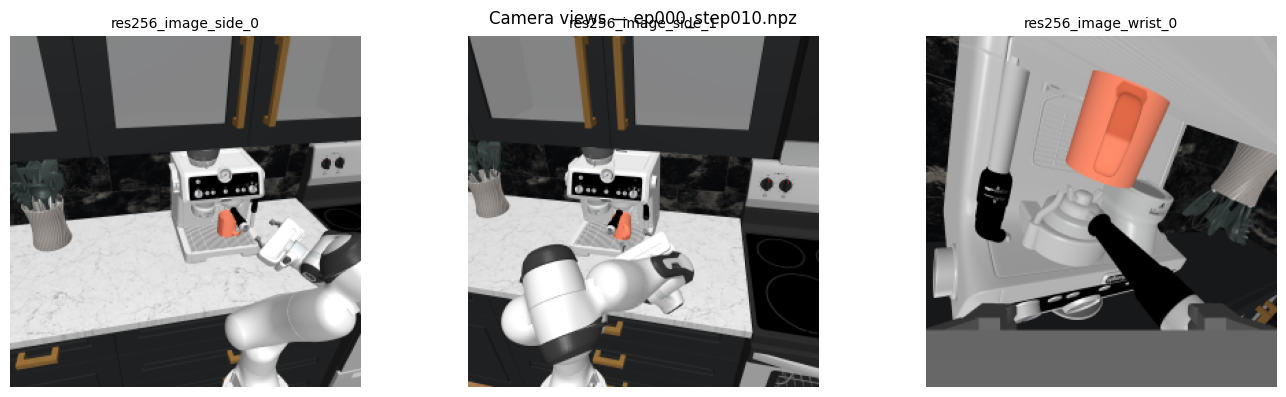

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)
Across all timesteps:
  x: mean=2.6243, 	var=0.0031, 	std=0.0516, 	range=0.3006
  y: mean=1.0387, 	var=0.0039, 	std=0.0571, 	range=0.2934
  z: mean=-1.7029, 	var=0.0021, 	std=0.0409, 	range=0.2009
Across final timestep only:
  x: mean=5.0635, 	var=0.0061, 	std=0.0784, 	range=0.5352
  y: mean=1.4611, 	var=0.0108, 	std=0.1041, 	range=0.5761
  z: mean=-3.0722, 	var=0.0078, 	std=0.0884, 	range=0.4404


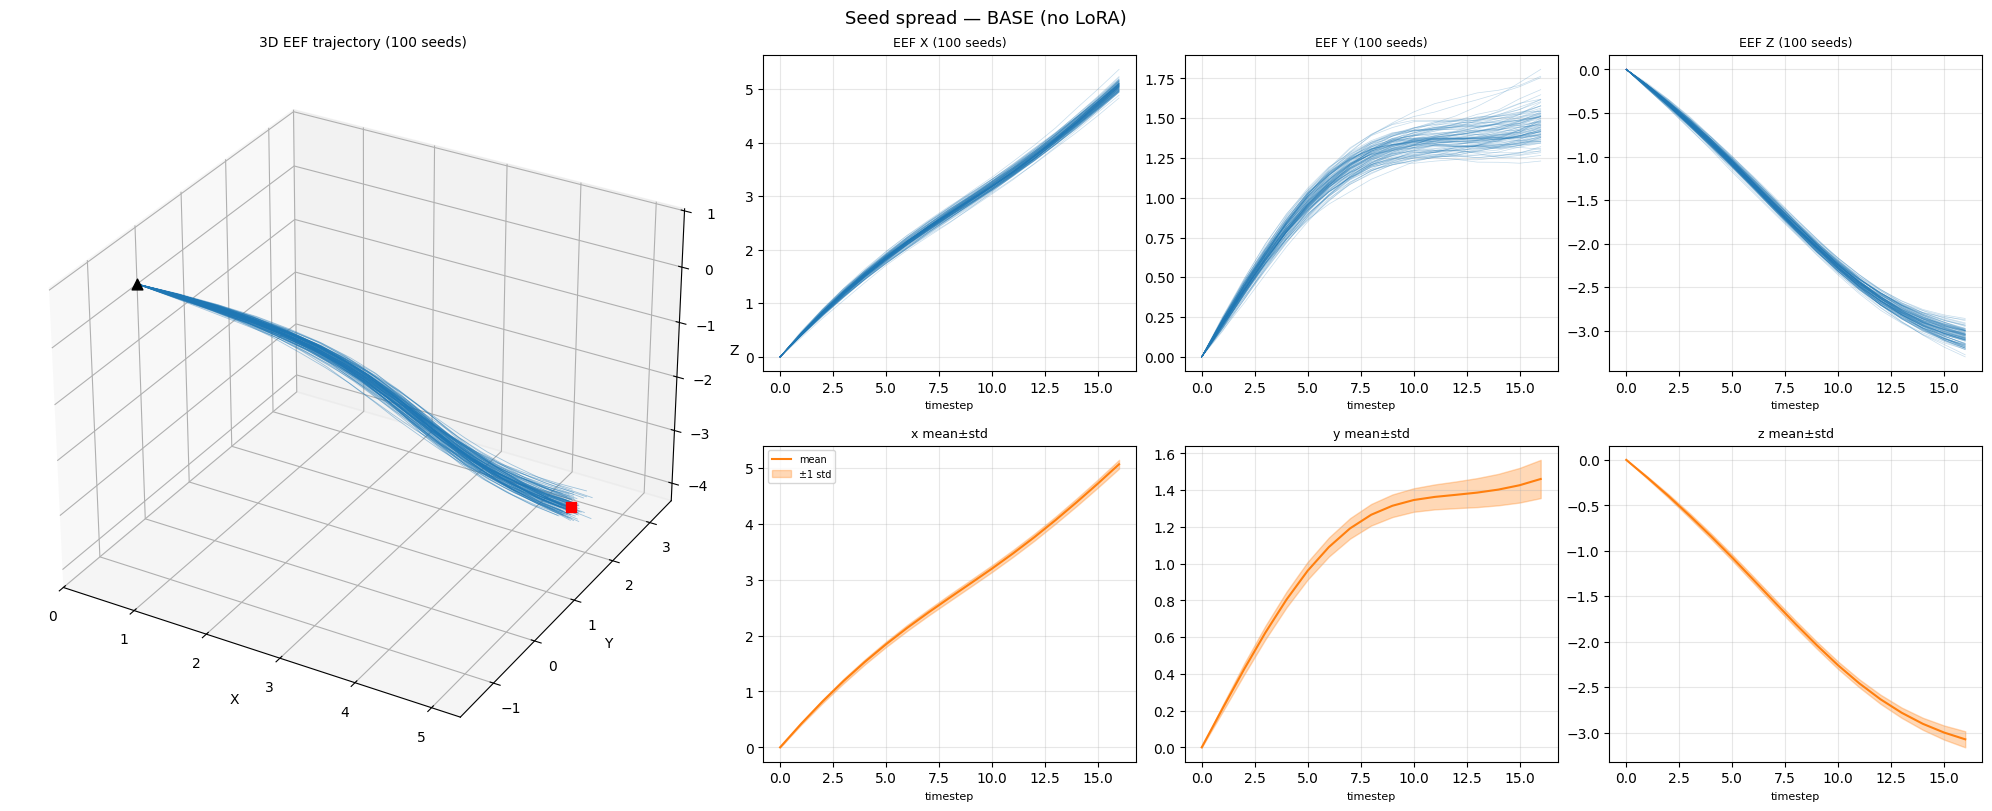


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
Across all timesteps:
  x: mean=3.4032, 	var=0.1385, 	std=0.3417, 	range=1.8980
  y: mean=1.4662, 	var=0.1227, 	std=0.3165, 	range=1.8503
  z: mean=-2.2453, 	var=0.0731, 	std=0.2468, 	range=1.3083
Across final timestep only:
  x: mean=6.3019, 	var=0.2943, 	std=0.5425, 	range=3.5273
  y: mean=2.0423, 	var=0.3046, 	std=0.5519, 	range=3.1736
  z: mean=-4.1411, 	var=0.1830, 	std=0.4278, 	range=2.2988


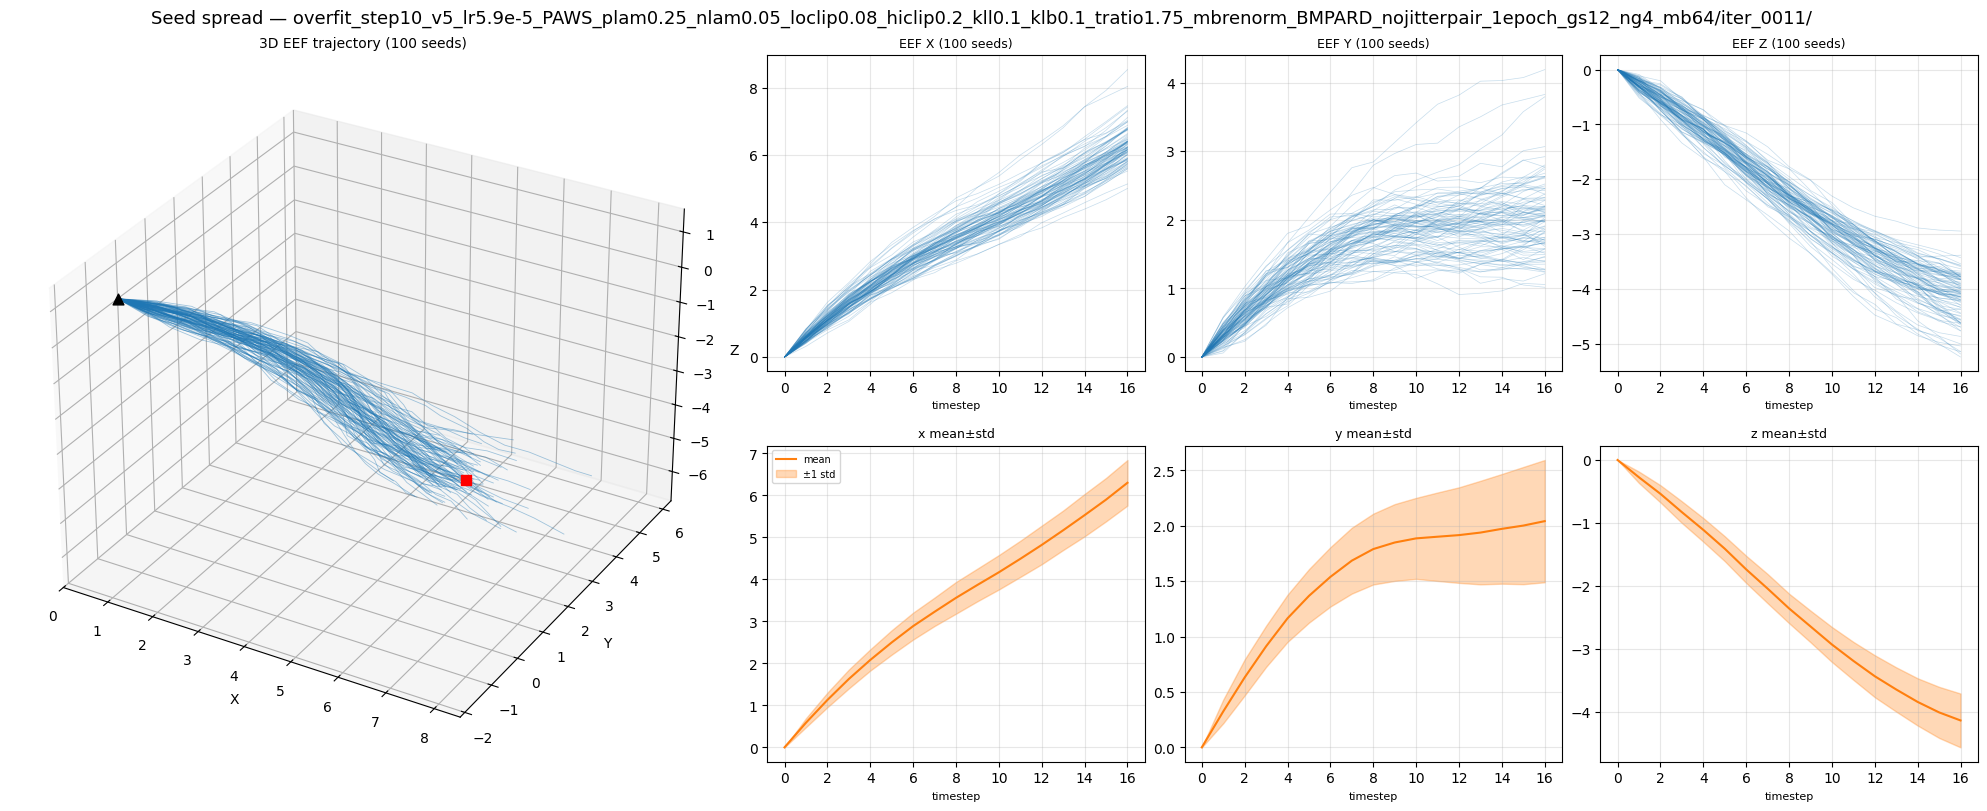


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017
Across all timesteps:
  x: mean=3.4730, 	var=0.1782, 	std=0.3871, 	range=2.1110
  y: mean=1.4234, 	var=0.1469, 	std=0.3471, 	range=1.9758
  z: mean=-2.1816, 	var=0.0880, 	std=0.2721, 	range=1.4604
Across final timestep only:
  x: mean=6.4384, 	var=0.3860, 	std=0.6213, 	range=4.0547
  y: mean=1.9766, 	var=0.3650, 	std=0.6041, 	range=3.3960
  z: mean=-4.0352, 	var=0.2135, 	std=0.4621, 	range=2.5488


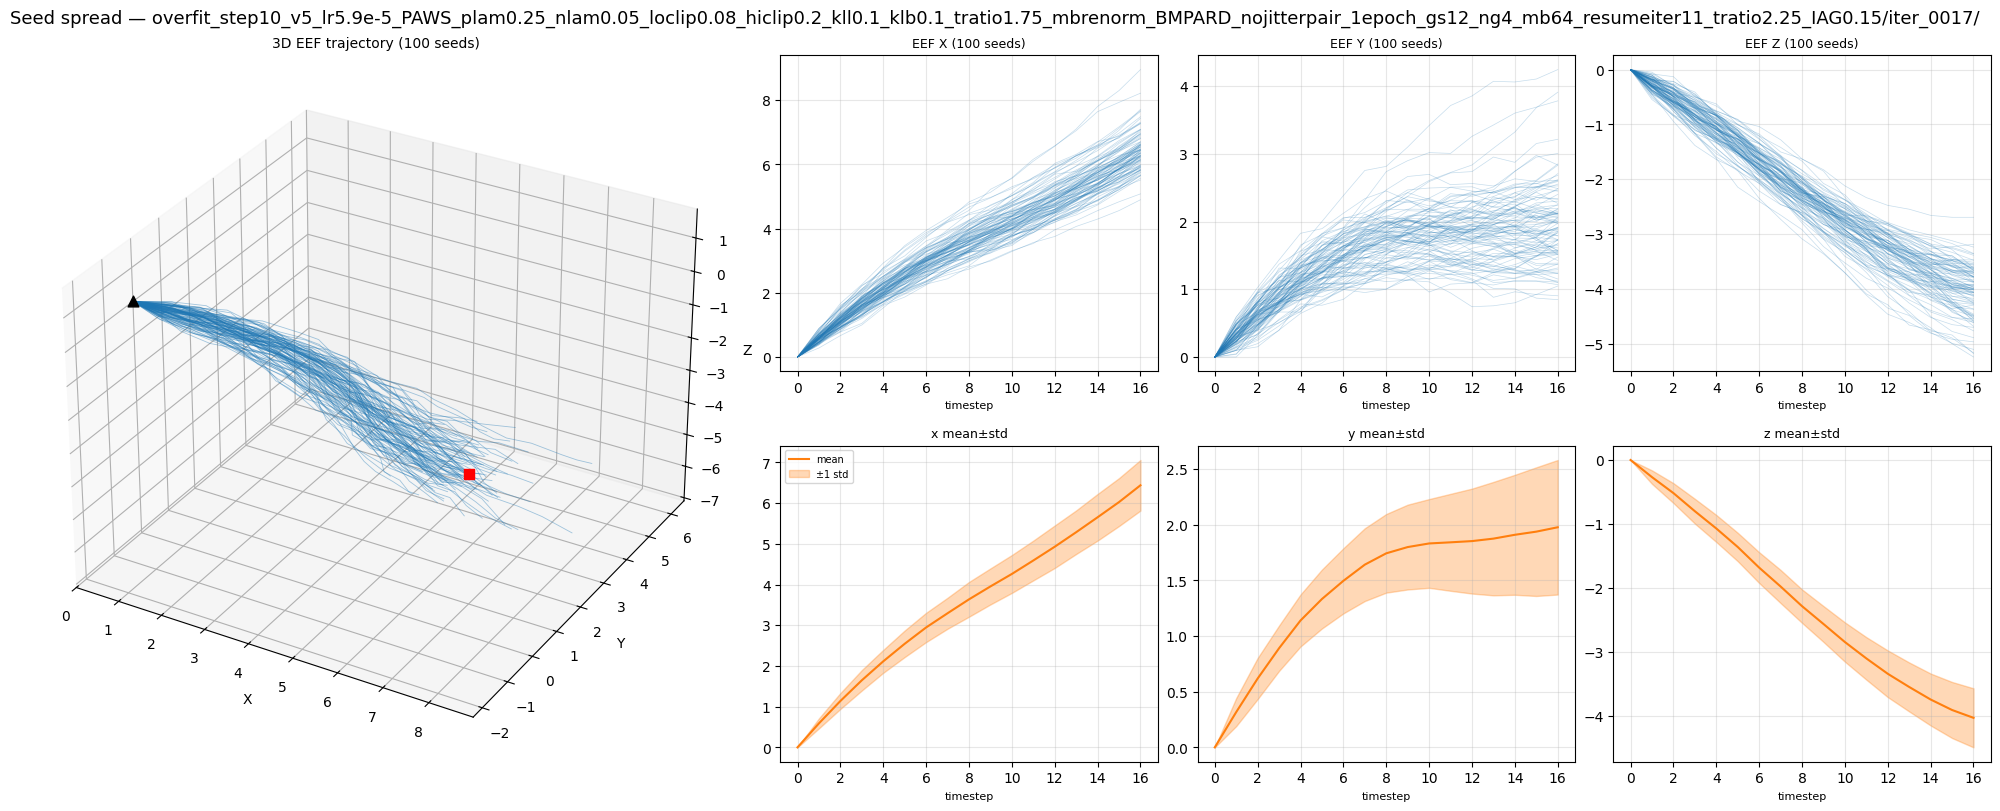

In [20]:
# Cell 5: Run the full comparison (base model + all checkpoints) for OBS_PATH.
# OBS_PATH is set to ...ep000_step010.npz in Cell 1. Re-run with a different path for
# any other observation, e.g. analyze_all_checkpoints("/path/to/other.npz").
_features, results = analyze_all_checkpoints(OBS_PATH)

## Cross-checkpoint summary

Final-timestep EEF-position std across the seeds, per checkpoint (and the base model).
Higher std = more action diversity driven by the initial noise; lower std = the
checkpoint has become more "decisive" / peaked for this observation.

checkpoint                                              std_x    std_y    std_z      mean
BASE (no LoRA)                                         0.0784   0.1041   0.0884    0.0903
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/   0.5425   0.5519   0.4278    0.5074
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017/   0.6213   0.6041   0.4621    0.5625


/mnt/scratch/tmp/ipykernel_17096/2195502949.py:19: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


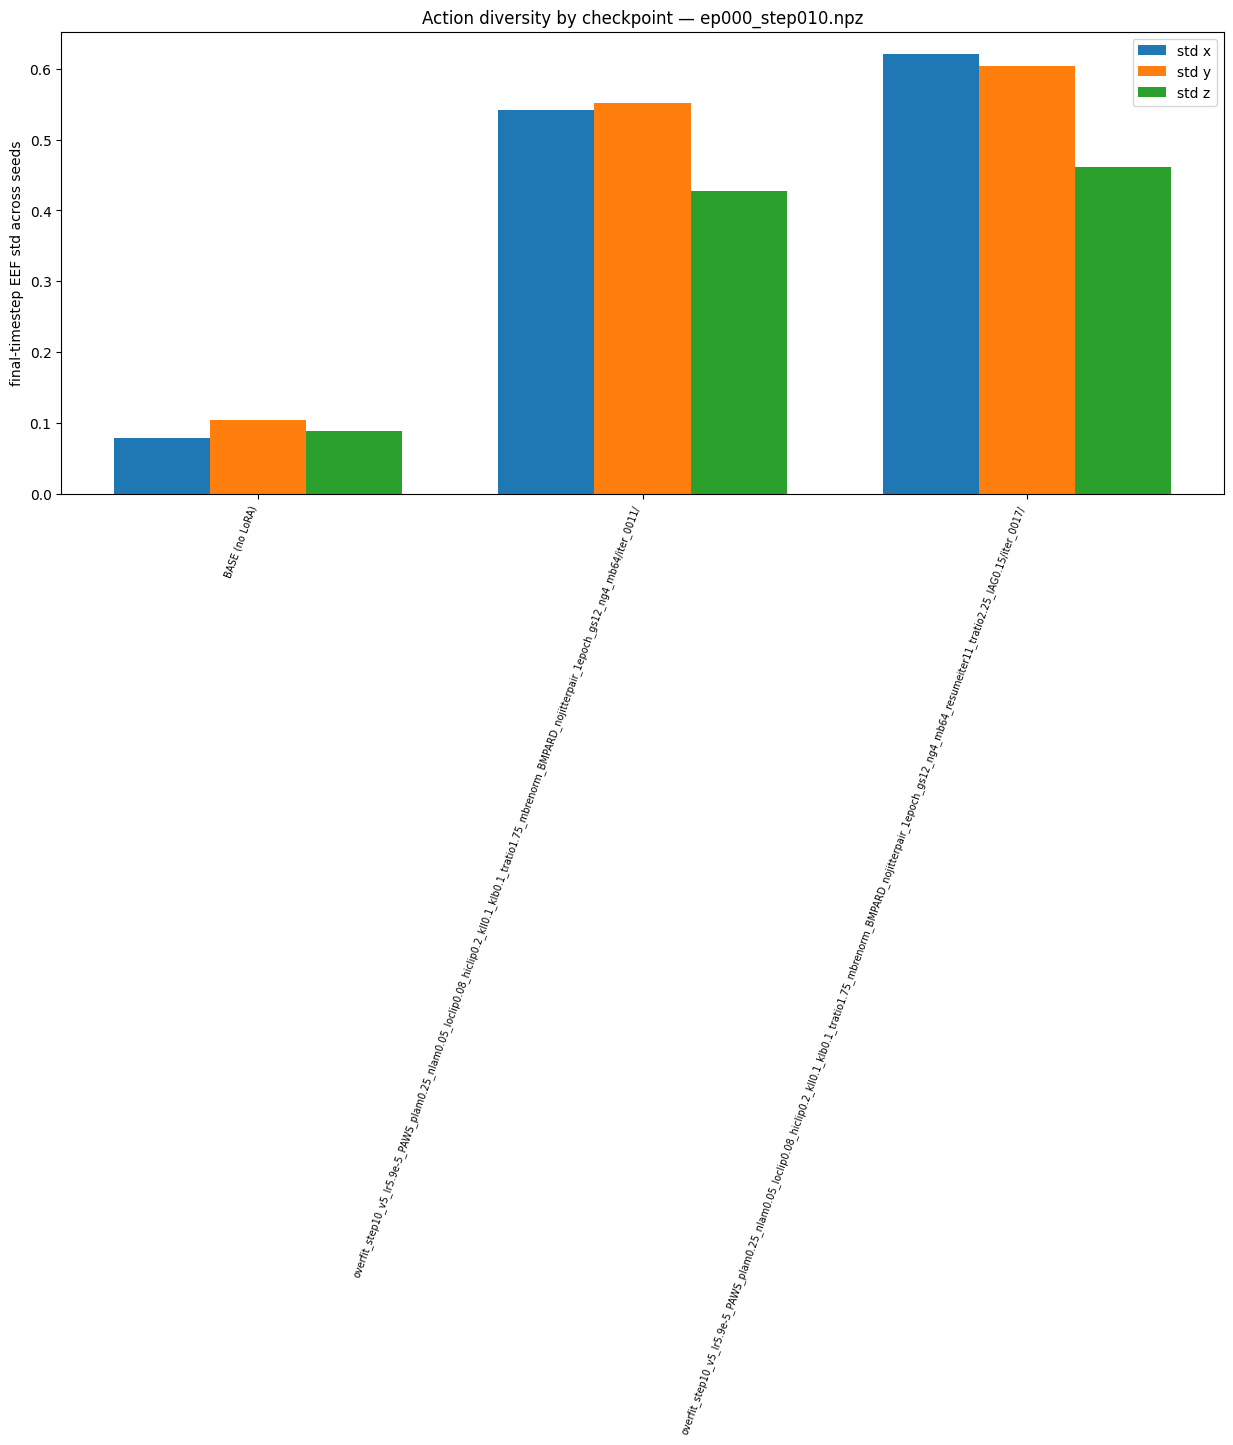

In [21]:
# Cell 6: Cross-checkpoint summary — final-timestep EEF position std across seeds.
labels_short = list(results.keys())
final_std = np.array([results[k]["final_std"] for k in labels_short])  # (n_ckpt, 3)

print(f"{'checkpoint':52s} {'std_x':>8s} {'std_y':>8s} {'std_z':>8s} {'mean':>9s}")
for k, fs in zip(labels_short, final_std):
    print(f"{k:52s} {fs[0]:8.4f} {fs[1]:8.4f} {fs[2]:8.4f} {fs.mean():9.4f}")

x = np.arange(len(labels_short))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, l in enumerate(["x", "y", "z"]):
    ax.bar(x + (i - 1) * w, final_std[:, i], w, label=f"std {l}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("final-timestep EEF std across seeds")
ax.set_title(f"Action diversity by checkpoint — {os.path.basename(OBS_PATH)}")
ax.legend()
plt.tight_layout()
plt.show()

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz
Task: ('pick the mug from under the coffee machine dispenser and place it on the counter',)


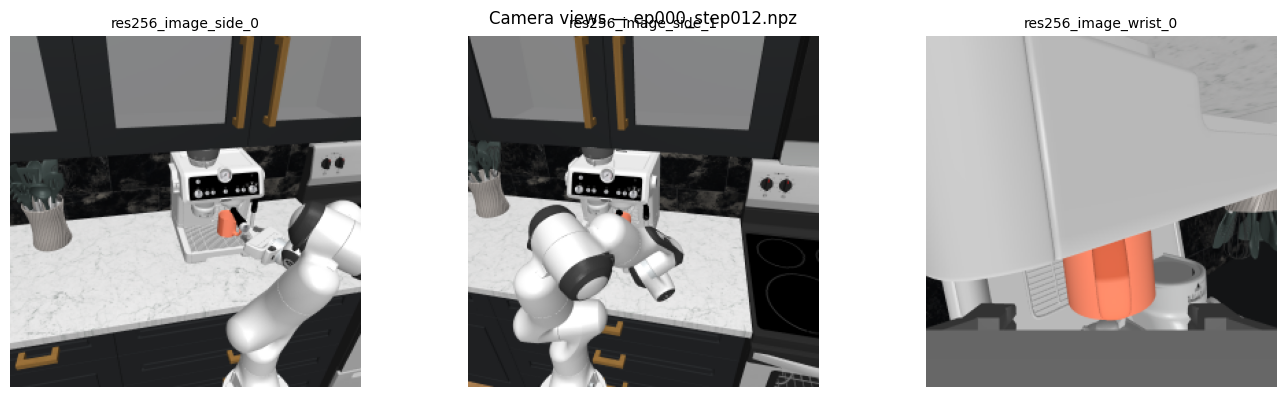

Backbone features: torch.Size([1, 295, 2048])

CHECKPOINT: BASE (no LoRA)
Across all timesteps:
  x: mean=1.6897, 	var=0.0023, 	std=0.0455, 	range=0.2434
  y: mean=0.6733, 	var=0.0234, 	std=0.1338, 	range=0.7270
  z: mean=-0.2346, 	var=0.0117, 	std=0.0873, 	range=0.4611
Across final timestep only:
  x: mean=3.0560, 	var=0.0046, 	std=0.0682, 	range=0.4199
  y: mean=1.4409, 	var=0.0742, 	std=0.2724, 	range=1.6533
  z: mean=-0.8299, 	var=0.0518, 	std=0.2277, 	range=1.2935


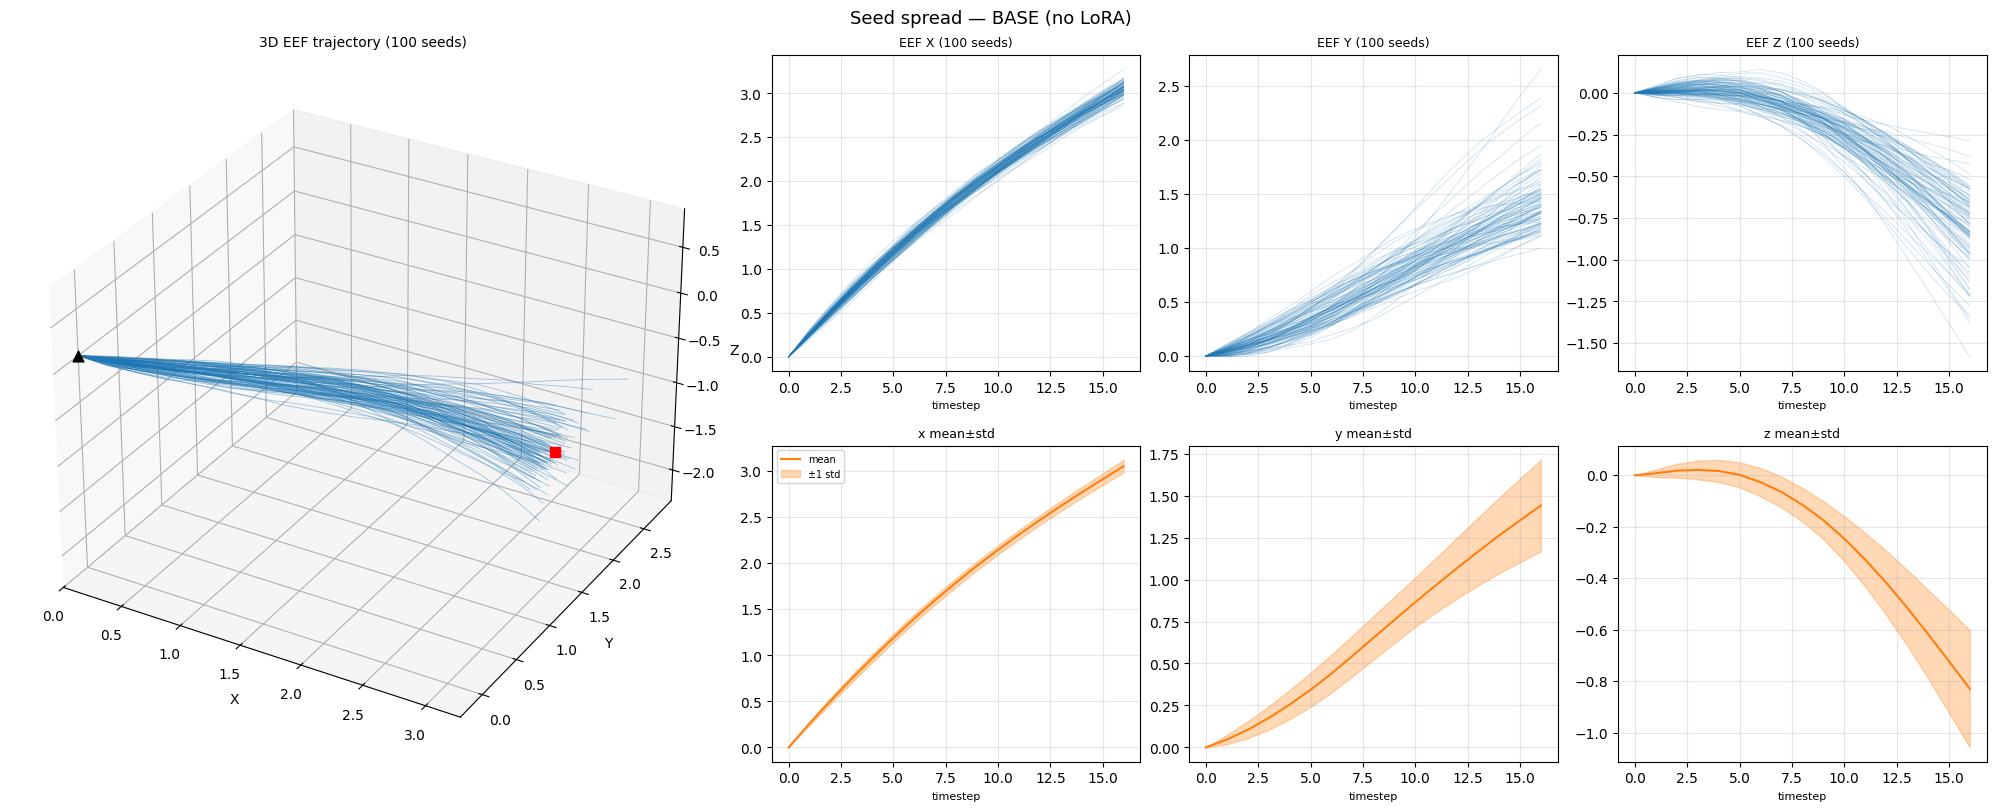


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
Across all timesteps:
  x: mean=2.1079, 	var=0.1036, 	std=0.2897, 	range=1.7805
  y: mean=1.1430, 	var=0.3843, 	std=0.5283, 	range=3.1593
  z: mean=-0.6483, 	var=0.1642, 	std=0.3449, 	range=1.8713
Across final timestep only:
  x: mean=3.9368, 	var=0.2537, 	std=0.5037, 	range=3.2588
  y: mean=2.4814, 	var=1.2692, 	std=1.1266, 	range=6.4526
  z: mean=-1.8604, 	var=0.5643, 	std=0.7512, 	range=4.3475


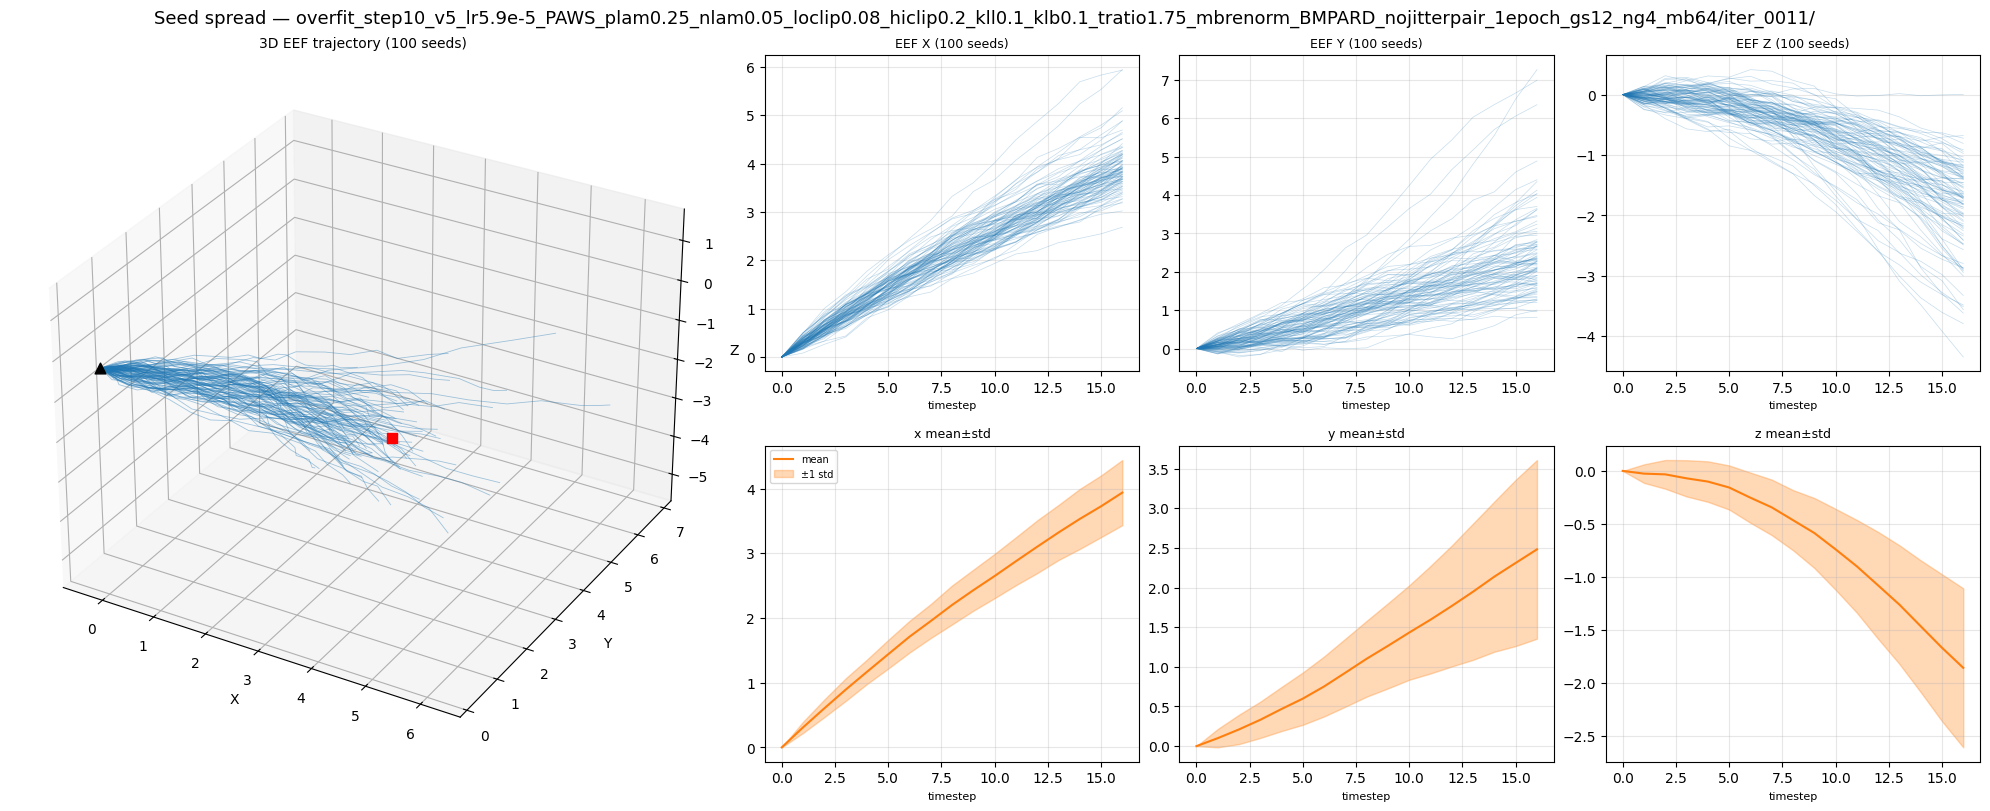


CHECKPOINT: overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017/
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017
Across all timesteps:
  x: mean=2.1127, 	var=0.1306, 	std=0.3273, 	range=1.8786
  y: mean=1.0752, 	var=0.3806, 	std=0.5305, 	range=3.1200
  z: mean=-0.6087, 	var=0.1653, 	std=0.3515, 	range=1.9444
Across final timestep only:
  x: mean=3.9477, 	var=0.3125, 	std=0.5590, 	range=3.6924
  y: mean=2.3439, 	var=1.2323, 	std=1.1101, 	range=6.4194
  z: mean=-1.7672, 	var=0.5441, 	std=0.7376, 	range=4.4266


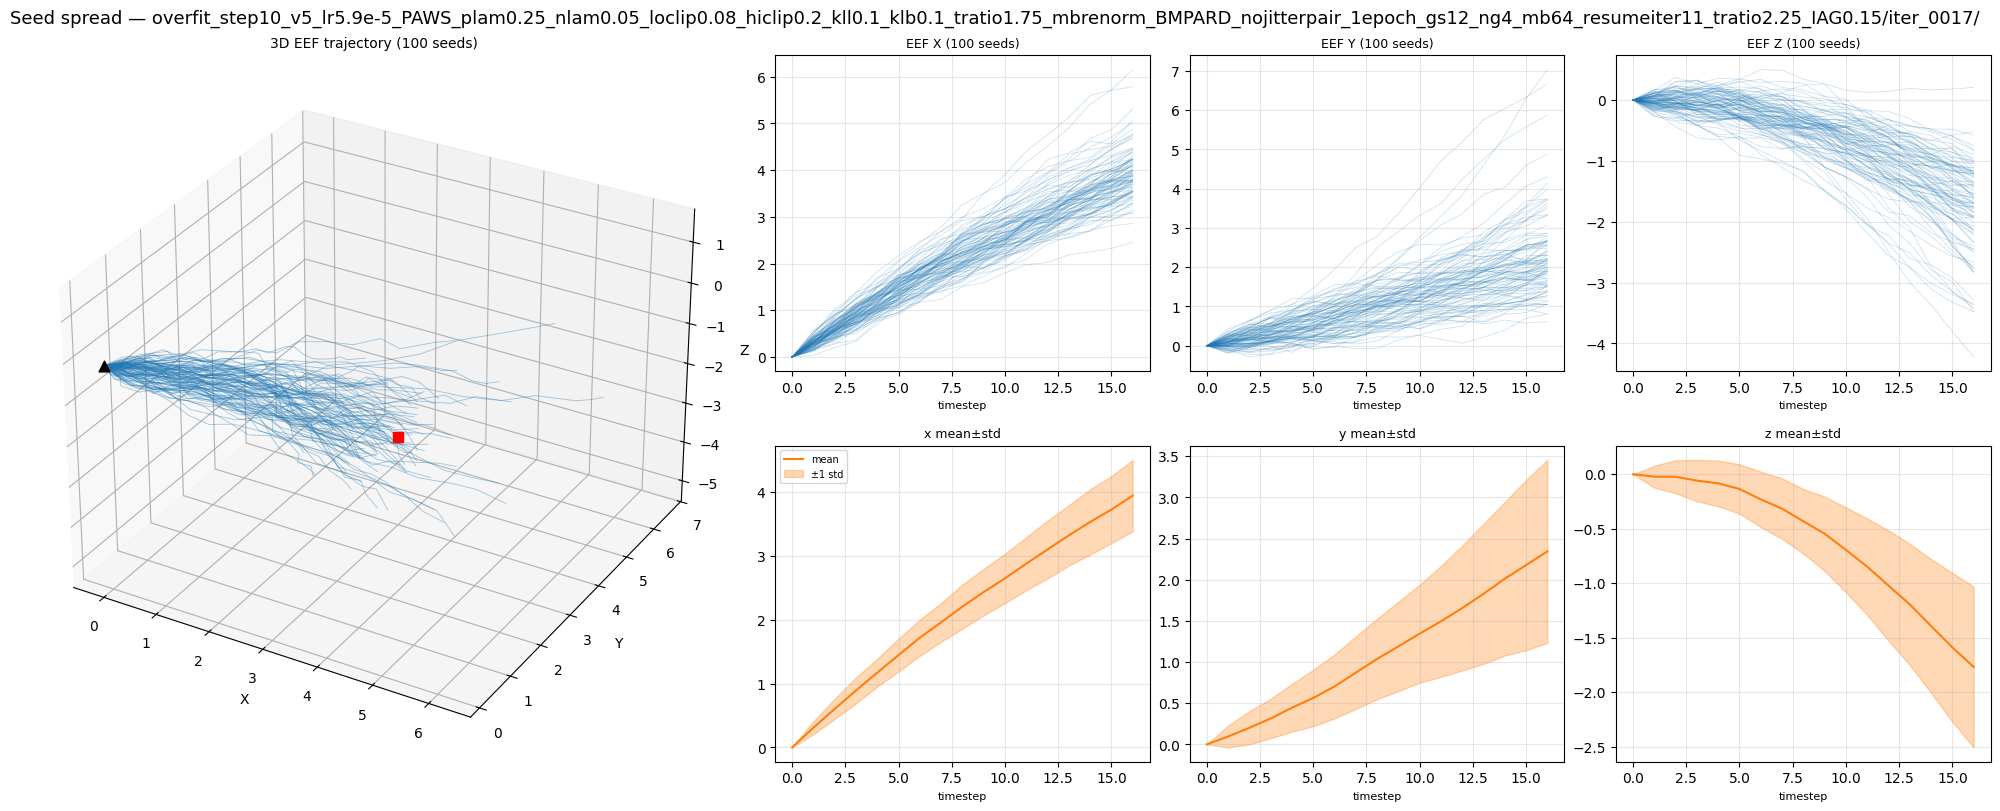

In [22]:
# Cell 7: Re-run the full comparison for a different observation (step 012).
OBS_PATH = "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz"
_features, results = analyze_all_checkpoints(OBS_PATH)

checkpoint                                              std_x    std_y    std_z      mean
BASE (no LoRA)                                         0.0682   0.2724   0.2277    0.1894
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011/   0.5037   1.1266   0.7512    0.7938
overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64_resumeiter11_tratio2.25_IAG0.15/iter_0017/   0.5590   1.1101   0.7376    0.8022


/mnt/scratch/tmp/ipykernel_17096/378827261.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


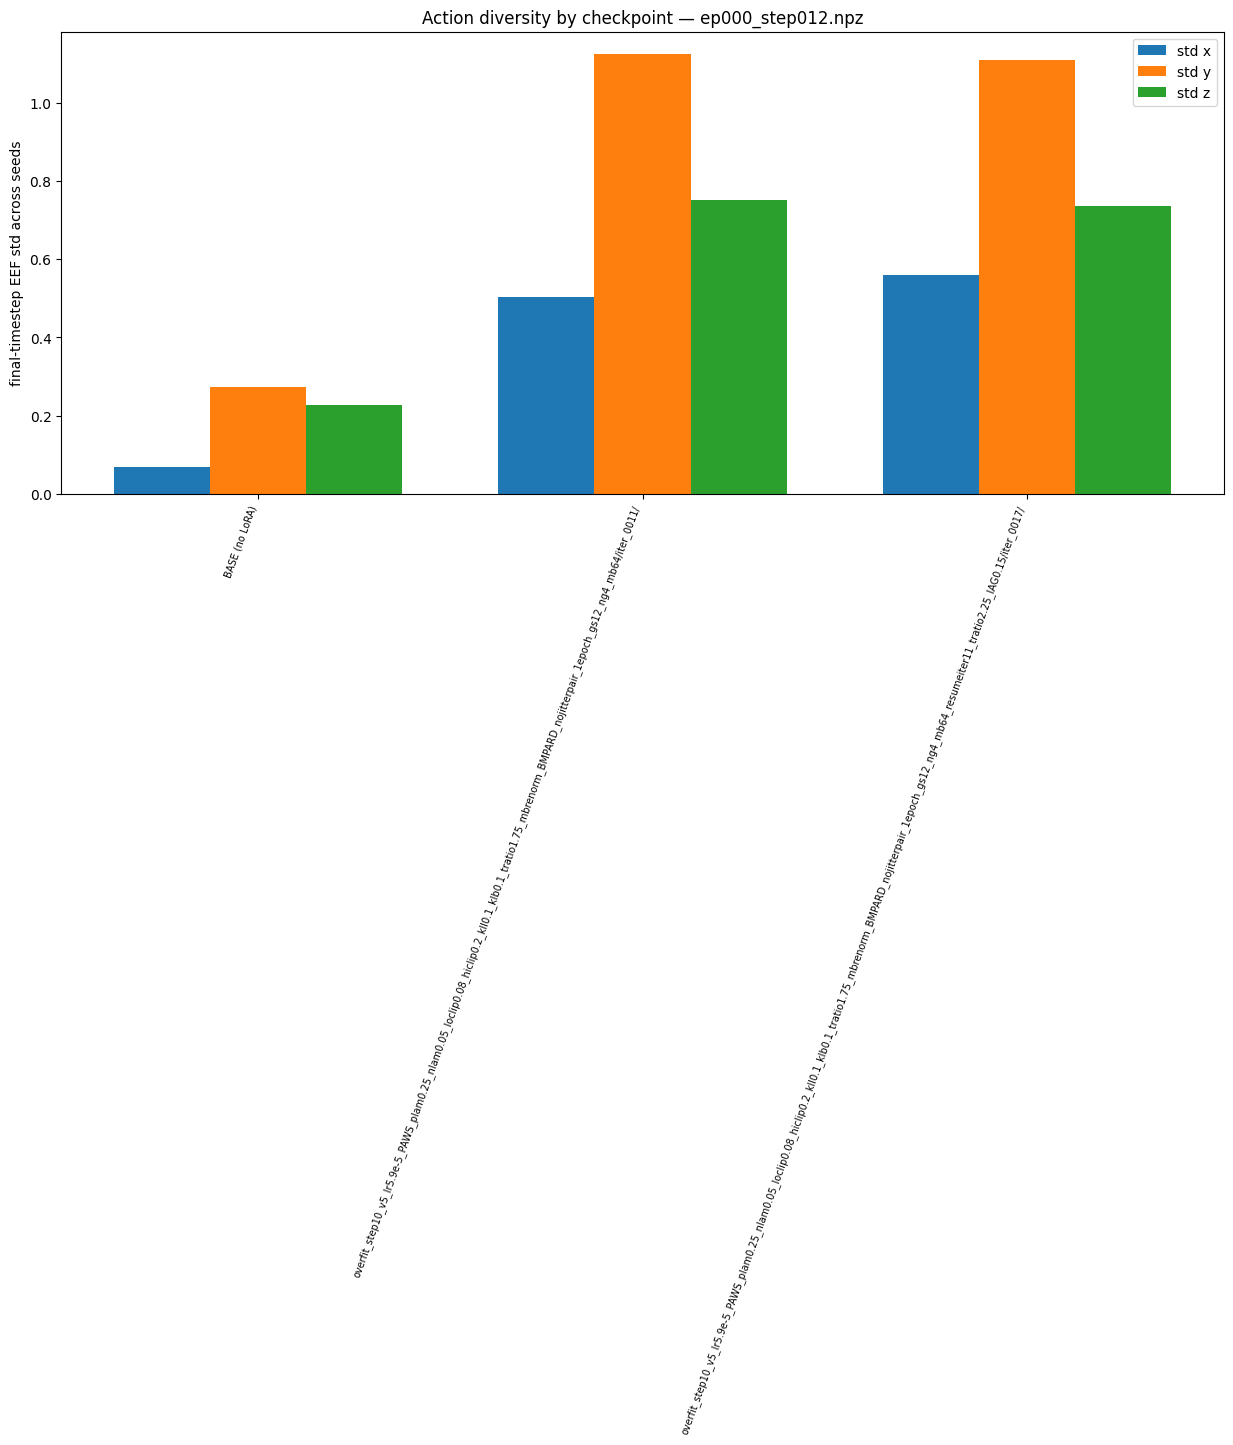

In [23]:
# Cell 8: Cross-checkpoint summary for the step-012 observation
# (identical to Cell 6, re-run against the results from the cell above).
labels_short = list(results.keys())
final_std = np.array([results[k]["final_std"] for k in labels_short])  # (n_ckpt, 3)

print(f"{'checkpoint':52s} {'std_x':>8s} {'std_y':>8s} {'std_z':>8s} {'mean':>9s}")
for k, fs in zip(labels_short, final_std):
    print(f"{k:52s} {fs[0]:8.4f} {fs[1]:8.4f} {fs[2]:8.4f} {fs.mean():9.4f}")

x = np.arange(len(labels_short))
w = 0.25
fig, ax = plt.subplots(figsize=(15, 6))
for i, l in enumerate(["x", "y", "z"]):
    ax.bar(x + (i - 1) * w, final_std[:, i], w, label=f"std {l}")
ax.set_xticks(x)
ax.set_xticklabels(labels_short, rotation=70, ha="right", fontsize=7)
ax.set_ylabel("final-timestep EEF std across seeds")
ax.set_title(f"Action diversity by checkpoint — {os.path.basename(OBS_PATH)}")
ax.legend()
plt.tight_layout()
plt.show()

## Step 1 — solver convergence: is the roughness the FIELD or the SOLVER?

Zero episodes, no simulator, ~2 min. The chunk is a 4-step Euler approximation

```
a = eps + 0.25 * sum_i v_theta(x_i, tau_i)
```

so roughness in `h` has two possible sources, with completely different fixes:

| | more Euler steps | fix |
|---|---|---|
| the **field** is jagged in `h` | converges to a still-jagged endpoint → roughness persists | training-side constraint (doc sections 4 / 10-H3) |
| the field is smooth but **curved**, and 4 steps can't track it | roughness falls and plateaus | `num_inference_timesteps: 4 -> 8` at serving. **No retraining.** |

The second branch is plausible, not a long shot: `ref_mse` *is* the non-straightness
of the flow and it tripled by iter 11 (0.0042 -> 0.0127), while the base model is
nearly rectified (v2 notebook: 1-step and 4-step means agree to <=0.55 units on a
3-16 unit trajectory). One cause — a field that outgrew its solver — would explain
both the roughness and the 4.4x wider relative dispersion.

Three numbers per `num_steps`, all on a shared seed set so the comparison is paired:

- **`pathjerk`** — normalized jerk. Does roughness fall, and does it plateau?
- **`rel_disp`** — final-position std / ||mean displacement||. Does the fan tighten?
- **`drift`** — ||mean trajectory(N) - mean trajectory(4)|| / ||mean displacement(4)||.
  **This is the cost side.** Raising `num_steps` at serving is a distribution shift:
  the LoRA was trained on (eps -> a) pairs from 4-step sampling, so the FM surrogate,
  the ratio and every advantage were computed there. Small drift => nearly free.
  Large drift => you have changed the policy and owe an SR run (>=3 seeds, since
  single-run SR noise is +-0.07) before adopting it.


Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz   (25 seeds, shared across num_steps)

BASE (no LoRA)
  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.06893      1.00    0.0147      1.00   0.0000
          8   0.16628      2.41    0.0333      2.27   0.0056
         16   0.26362      3.82    0.0478      3.26   0.0103
         32   0.34593      5.02    0.0557      3.79   0.0110

CHECKPOINT: iter_0011
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
  num_steps  pathjerk  vs 4step  rel_disp  vs 4step    drift
          4   0.52257      1.00    0.0666      1.00   0.0000
          8   0.43977      0.84    0.0844      1.27   0.0136
         16   0.47957      0.92    0.0980      1.47   0.0237
         32   0.54382      1.04    0.1057      1.59   0.0256

CHECK

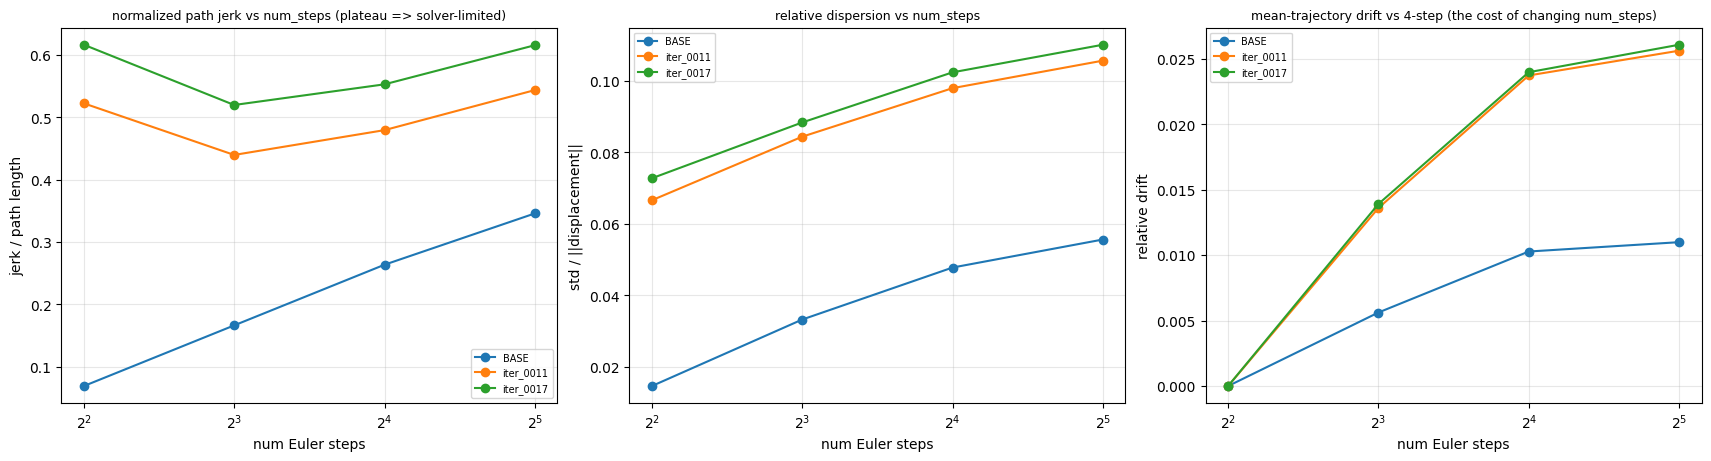

In [24]:
# Cell 13: solver_convergence — sweep num_steps on a shared seed set.
# Cost: n_seeds * sum(steps_list) forwards per checkpoint (25 * 60 = 1500 at the
# defaults). Nothing here runs the simulator or produces a success rate.
def _traj_from_chunk(lab, features, a, eef_key=EEF_KEY):
    """Decode a raw chunk to the integrated EEF path, matching
    TrajectoryVisualizer.add_trajectory (0 prepended + cumsum)."""
    d = lab.decode_raw_actions(a, features.states)
    deltas = d[eef_key][0][:, :3]
    return np.concatenate([np.zeros((1, 3)), np.cumsum(deltas, axis=0)], axis=0), deltas


def solver_convergence(lab, features, label, steps_list=(4, 8, 16, 32), n_seeds=25):
    out = {"label": label, "steps": list(steps_list)}
    per_steps = {}
    for ns in steps_list:
        paths, jerks = [], []
        for s in range(n_seeds):                       # SAME seeds for every ns
            res = lab.denoise(features, seed=s, num_steps=ns)
            pos, deltas = _traj_from_chunk(lab, features, res.action_pred)
            paths.append(pos)
            L = float(np.linalg.norm(deltas, axis=1).sum())
            J = float(np.linalg.norm(np.diff(pos, n=3, axis=0), axis=1).sum())
            jerks.append(J / max(L, 1e-9))
        P = np.stack(paths)                            # (n_seeds, T+1, 3)
        mean_traj = P.mean(axis=0)
        disp = float(np.linalg.norm(mean_traj[-1]))
        per_steps[ns] = {
            "pathjerk": float(np.mean(jerks)),
            "rel_disp": float(np.sqrt(P[:, -1].var(axis=0)).mean() / max(disp, 1e-9)),
            "mean_traj": mean_traj,
            "disp": disp,
        }
    ref = per_steps[steps_list[0]]
    for ns in steps_list:                              # drift vs the 4-step mean
        per_steps[ns]["drift"] = float(
            np.linalg.norm(per_steps[ns]["mean_traj"] - ref["mean_traj"], axis=1).mean()
            / max(ref["disp"], 1e-9))
    out["per_steps"] = per_steps

    print(f"  {'num_steps':>9s} {'pathjerk':>9s} {'vs 4step':>9s} "
          f"{'rel_disp':>9s} {'vs 4step':>9s} {'drift':>8s}")
    j4, d4 = ref["pathjerk"], ref["rel_disp"]
    for ns in steps_list:
        v = per_steps[ns]
        print(f"  {ns:9d} {v['pathjerk']:9.5f} {v['pathjerk'] / max(j4, 1e-12):9.2f} "
              f"{v['rel_disp']:9.4f} {v['rel_disp'] / max(d4, 1e-12):9.2f} "
              f"{v['drift']:8.4f}")
    return out


def run_solver_sweep(obs_path, steps_list=(4, 8, 16, 32), n_seeds=25,
                     include_base=True):
    obs = DenoisingLab.load_observation(obs_path)
    features = lab.encode_features_from_sim_obs(obs)
    print(f"Observation: {obs_path}   ({n_seeds} seeds, shared across num_steps)\n")
    results = {}
    if include_base:
        print("=" * 90); print("BASE (no LoRA)"); print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results["BASE"] = solver_convergence(lab, features, "BASE",
                                                 steps_list, n_seeds)
    for ckpt_rel in CHECKPOINTS:
        lbl = ckpt_rel.rstrip("/").split("/")[-1]
        print("\n" + "=" * 90); print(f"CHECKPOINT: {lbl}"); print("=" * 90)
        load_lora_checkpoint(lab.model, os.path.join(REPO_ROOT, ckpt_rel))
        results[lbl] = solver_convergence(lab, features, lbl, steps_list, n_seeds)

    print("\n" + "=" * 90); print("VERDICT"); print("=" * 90)
    for k, v in results.items():
        if k == "BASE":
            continue
        ps, sl = v["per_steps"], v["steps"]
        n_lo, n_hi = sl[0], sl[-1]          # n_lo = 4 (as trained/served today)
        fall = 1.0 - ps[n_hi]["pathjerk"] / max(ps[n_lo]["pathjerk"], 1e-12)
        drift = ps[n_hi]["drift"]
        print(f"\n{k}: jerk falls {fall * 100:+.0f}% from {n_lo} to {n_hi} steps, "
              f"mean-trajectory drift {drift:.3f}")
        if fall < 0.10:
            print("  -> SOLVER IS NOT THE PROBLEM. The field itself is rough; the")
            print("     training-side constraint is required. More inference steps")
            print("     buy nothing here.")
        elif drift < 0.05:
            print("  -> SOLVER-LIMITED and the mean action barely moves. Try")
            print("     num_inference_timesteps 4 -> 8 at serving FIRST: it may")
            print("     recover smoothness with no retraining. Confirm with an SR")
            print("     run (>=3 seeds) before adopting.")
        else:
            print("  -> SOLVER-LIMITED but the mean action moves substantially")
            print(f"     ({drift:.3f}). Raising num_steps is a real policy change, not")
            print("     a free fix — it needs an SR run. The training-side constraint")
            print("     is the lower-risk route.")
    return results


_solver_010 = run_solver_sweep(
    "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)
for k, v in _solver_010.items():
    sl = v["steps"]
    axes[0].plot(sl, [v["per_steps"][n]["pathjerk"] for n in sl], "-o", label=k)
    axes[1].plot(sl, [v["per_steps"][n]["rel_disp"] for n in sl], "-o", label=k)
    axes[2].plot(sl, [v["per_steps"][n]["drift"] for n in sl], "-o", label=k)
for ax, ttl, yl in zip(axes,
        ["normalized path jerk vs num_steps (plateau => solver-limited)",
         "relative dispersion vs num_steps",
         "mean-trajectory drift vs 4-step (the cost of changing num_steps)"],
        ["jerk / path length", "std / ||displacement||", "relative drift"]):
    ax.set_title(ttl, fontsize=9); ax.set_xlabel("num Euler steps"); ax.set_ylabel(yl)
    ax.set_xscale("log", base=2); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.show()


## Measure before you build — is the residual *rougher*, or just *bigger*?

The jerk constraint penalizes the roughness of the **velocity residual**

```
r = v_θ(x_τ, τ) − (a − ε)          x_τ = (1−τ)·ε + τ·a
```

along the horizon axis `h`. This matters because of the exact identity

```
â_θ(τ) := x_τ + (1−τ)·v_θ(x_τ, τ)  =  a + (1−τ)·r
```

i.e. `r` *is* the deviation of the model's implied endpoint from the chunk it
actually produced. (Note ε cancels identically — that is the definition of the FM
target, not something the optimizer learns.)

Two independent things can make the produced chunk rough:

| | statistic | who fixes it |
|---|---|---|
| the residual got **bigger** | `M = mean(r²)` — this is `ref_mse` | base-model KL / a gain cap |
| the residual got **rougher** | `HF = mean((D²r)²) / (6·M)` — dimensionless | **the jerk hinge** |

`HF` is normalized so that `HF = 0` ⟺ `r` is constant along `h`, `HF = 1` ⟺ `r`
is white along `h` (the `(1,−2,1)` stencil has squared norm 6), and `HF → 8/3` for
a maximally alternating residual. Because it is scale-free, it separates "the
residual grew" — which AWR and erosion legitimately cause — from "the residual
became rough", which is the pathology.

**Decision rule** (printed at the end of the run):

- `HF ratio ≈ 1` **and** path-jerk ratio `≈ 1` → intra-chunk roughness is not the
  problem. Go run the 4-vs-8-step Euler test instead.
- `HF ratio ≈ 1` **but** path-jerk ratio `≫ 1` → the roughness came from
  **magnitude** growth, not spectrum. The hinge will not help; use the gain cap.
- `HF ratio ≫ 1` → spectral roughening confirmed. Build the hinge and set
  `HF_ref` to the BASE row printed below.

Nothing here is hardcoded: the action-dim layout is read from the checkpoint.


In [25]:
# Cell 9: Action-dim layout, read from the CHECKPOINT (self-verifying).
#
# Mirrors processing_gr00t_n1d6.decode_action (:239-246) and
# grpo_server.compute_action_mask (:278): walk this embodiment's action
# modality_keys IN ORDER, take each key's normalized `dim`, accumulate contiguous
# slices. If this checkpoint's layout differs from the expected PandaOmron one,
# you see it in the printout rather than silently masking the wrong columns.
TAG = lab.embodiment_tag.value
_acfg = lab.modality_configs["action"]
_norm = lab.processor.state_action_processor.norm_params[TAG]["action"]

ACTION_HORIZON_VALID = len(_acfg.delta_indices)          # 16 for PandaOmron
_layout, _start = [], 0
for _key in _acfg.modality_keys:
    _d = _norm[_key]["dim"]
    _d = int(_d.item() if hasattr(_d, "item") else _d)
    _layout.append((_key, _start, _start + _d))
    _start += _d
N_VALID_DIMS = _start

# Discrete 0/1 channels — EXCLUDED from every roughness measure. robocasa's
# PandaOmronKeyConverter.unmap_action thresholds both at 0.5, so a grasp and a
# base-mode switch ARE step functions and must stay free to step.
DISCRETE_KEYS = {"gripper_close", "control_mode"}

# base_motion is gated by control_mode (HybridMobileBase makes arm and base
# mutually exclusive), so its roughness can be inert in arm mode. Keep it OUT of
# the default set so the constraint's capacity goes to the channel the plots
# actually show; flip to True to include it and compare.
INCLUDE_BASE_MOTION = False

C_DIMS, C_KEYS = [], []
for _key, _lo, _hi in _layout:
    _short = _key.split(".")[-1]
    if _short in DISCRETE_KEYS:
        continue
    if _short == "base_motion" and not INCLUDE_BASE_MOTION:
        continue
    C_DIMS.extend(range(_lo, _hi))
    C_KEYS.append(_short)

# Measure the FULL valid horizon, not just the executed prefix. Three reasons:
#   1. compute_fm_log_prob masks with action_mask = the full valid rectangle
#      (16x12 here), so ref_mse / the ratio / every advantage already cover all 16
#      steps. Measuring M over 8 would make smooth/M_mean non-comparable to
#      ref_mse/mean.
#   2. 14 second-differences instead of 6 -> less than half the per-row variance,
#      which is what keeps a per-row relu gate from chattering.
#   3. n_action_steps is a DEPLOYMENT knob; the 16-step horizon is a property of
#      the checkpoint (delta_indices). Baking the former into the objective means a
#      later --n_action_steps 16 run executes steps never trained to be smooth.
# The DiT also emits the chunk jointly (self-attention over action tokens), so
# nothing keeps tail degradation out of the head.
H_MEASURE = ACTION_HORIZON_VALID

# Executed prefix — used ONLY to split the diagnostic into head / tail below, so
# we can see empirically whether roughness is uniform in h or tail-concentrated.
N_ACTION_STEPS = 8

# tau_centers: GRPOConfig default (late-biased). Keep in sync with the run.
TAU_CENTERS = [0.0, 0.25, 0.35, 0.5, 0.6, 0.75]

print(f"embodiment={TAG}  valid_horizon={ACTION_HORIZON_VALID}  valid_dims={N_VALID_DIMS}")
print(f"raw model output = ({lab.action_horizon}, {lab.action_dim}) -> valid rectangle "
      f"[:{ACTION_HORIZON_VALID}, :{N_VALID_DIMS}]")
print("\naction dim layout (order comes from the checkpoint, NOT from the repo):")
for _key, _lo, _hi in _layout:
    _short = _key.split(".")[-1]
    _tag = "DISCRETE - excluded" if _short in DISCRETE_KEYS else (
        "excluded (INCLUDE_BASE_MOTION=False)"
        if _short == "base_motion" and not INCLUDE_BASE_MOTION else "in C")
    print(f"  [{_lo:2d}:{_hi:2d}]  {_short:28s} dim={_hi - _lo}  {_tag}")
print(f"\nC = {C_KEYS} -> {len(C_DIMS)} dims: {C_DIMS}")
print(f"h range measured: 0..{H_MEASURE - 1} (FULL valid horizon), "
      f"{max(0, H_MEASURE - 2)} second-differences")
print(f"diagnostic split: head = h<{N_ACTION_STEPS} (executed), "
      f"tail = h>={N_ACTION_STEPS} (discarded at n_action_steps={N_ACTION_STEPS})")
print(f"tau centers: {TAU_CENTERS}")


embodiment=robocasa_panda_omron  valid_horizon=16  valid_dims=12
raw model output = (50, 128) -> valid rectangle [:16, :12]

action dim layout (order comes from the checkpoint, NOT from the repo):
  [ 0: 3]  end_effector_position        dim=3  in C
  [ 3: 6]  end_effector_rotation        dim=3  in C
  [ 6: 7]  gripper_close                dim=1  DISCRETE - excluded
  [ 7:11]  base_motion                  dim=4  excluded (INCLUDE_BASE_MOTION=False)
  [11:12]  control_mode                 dim=1  DISCRETE - excluded

C = ['end_effector_position', 'end_effector_rotation'] -> 6 dims: [0, 1, 2, 3, 4, 5]
h range measured: 0..15 (FULL valid horizon), 14 second-differences
diagnostic split: head = h<8 (executed), tail = h>=8 (discarded at n_action_steps=8)
tau centers: [0.0, 0.25, 0.35, 0.5, 0.6, 0.75]


In [26]:
# Cell 10: measure_roughness — residual spectrum (M, HF) + scale-controlled path jerk.
#
# One pass over seeds computes BOTH families, so this adds no denoise() calls
# beyond the ones it needs:
#   * residual: for each tau, build the FM interpolant x_tau = (1-tau)*eps + tau*a,
#     forward the DiT once, and take r = v_theta - (a - eps). This is exactly the
#     tensor compute_fm_log_prob squares at fm_log_prob.py:253.
#   * path jerk: decode the chunk to EEF deltas, integrate to positions the same
#     way TrajectoryVisualizer.add_trajectory does (0 prepended + cumsum), then
#     report sum(|3rd difference|) / path_length. The NORMALIZATION is the point:
#     LoRA paths are 28-43% longer, so RAW jerk rises mechanically and cannot
#     distinguish "rougher" from "bigger".
#
# Slicing to the valid rectangle happens BEFORE differencing — differencing the
# padded (50, 128) output would straddle the pad boundary and return garbage.
#
# Not batched over seeds on purpose: features has batch 1, and broadcasting a
# batch-1 vl_embeds against batch-S actions in cross-attention is a silent-
# wrongness risk. n_seeds=25 is plenty for a distributional statistic.
import numpy as np
import torch


def _d2(u):
    """Second difference along the horizon axis (axis=1) of an (N, H, D) array."""
    return u[:, 2:] - 2.0 * u[:, 1:-1] + u[:, :-2]


def measure_roughness(lab, features, label, n_seeds=25, tau_centers=None,
                      dims=None, h_measure=None, num_steps=4, eef_key=EEF_KEY):
    tau_centers = TAU_CENTERS if tau_centers is None else tau_centers
    dims = C_DIMS if dims is None else dims
    H = H_MEASURE if h_measure is None else h_measure
    nb = lab.num_timestep_buckets

    per_tau = {tau: {"M": [], "R": [], "M_head": [], "R_head": [],
                     "M_tail": [], "R_tail": []} for tau in tau_centers}
    act_M, act_R, path_jerk, path_len = [], [], [], []

    # Head/tail windows for the diagnostic split. _d2 returns (N, H-2, D), so
    # index j covers h in [j, j+2]. "head" = windows entirely inside the executed
    # prefix; "tail" = windows entirely inside the discarded remainder. The two
    # straddling windows belong to neither and are dropped from the split only
    # (never from the full measure).
    he = min(N_ACTION_STEPS, H)
    head_sl, tail_sl = slice(0, max(he - 2, 0)), slice(he, max(H - 2, 0))

    # Full power spectrum of r along h. HF is only a 2-moment SUMMARY of this, and
    # it SATURATES: a residual that is even 50% white already reads HF~0.93, so if
    # the base residual is unstructured error (the null hypothesis for a well-fit
    # regression) HF_base ~ 1 and there is <2.7x headroom before the 8/3 ceiling.
    # The spectrum says directly whether HF is a usable instrument here: flat =
    # white = HF pinned at 1 = use the M cap instead, not the HF hinge.
    spec_acc = np.zeros(H // 2 + 1)
    spec_n = 0

    for s in range(n_seeds):
        res = lab.denoise(features, seed=s, num_steps=num_steps)
        a, eps = res.action_pred, res.initial_noise
        v_target = a - eps                                    # FM velocity target

        # --- roughness of the produced chunk itself (normalized action space) ---
        a_v = a[:, :H, :].float()[:, :, dims]
        act_M.append(a_v.pow(2).mean().item())
        act_R.append(_d2(a_v).pow(2).mean().item())

        # --- scale-controlled jerk of the decoded EEF path (physical units) ---
        d = lab.decode_raw_actions(a, features.states)
        deltas = d[eef_key][0][:, :3]                          # (T, 3)
        pos = np.concatenate([np.zeros((1, 3)), np.cumsum(deltas, axis=0)], axis=0)
        L = float(np.linalg.norm(deltas, axis=1).sum())
        J = float(np.linalg.norm(np.diff(pos, n=3, axis=0), axis=1).sum())
        path_len.append(L)
        path_jerk.append(J / max(L, 1e-9))

        # --- velocity residual at each tau center ---
        for tau in tau_centers:
            x_tau = (1.0 - tau) * eps + tau * a
            # denoise_single_step computes t_cont = step_idx / num_total_steps, so
            # passing num_total_steps = num_timestep_buckets hits tau exactly.
            v, _ = lab.denoise_single_step(features, x_tau, round(tau * nb), nb)
            r = (v - v_target)[:, :H, :].float()[:, :, dims]
            d2r = _d2(r)
            per_tau[tau]["M"].append(r.pow(2).mean().item())
            per_tau[tau]["R"].append(d2r.pow(2).mean().item())
            # pooled over tau: normalized |rfft|^2 along h, averaged over dims
            _p = np.abs(np.fft.rfft(r.cpu().numpy(), axis=1)) ** 2
            spec_acc += (_p / max(_p.sum(axis=1, keepdims=True).mean(), 1e-30)
                         ).mean(axis=(0, 2))
            spec_n += 1
            # head / tail split — diagnostic only, never used by the loss
            if head_sl.stop > head_sl.start:
                per_tau[tau]["M_head"].append(r[:, :he].pow(2).mean().item())
                per_tau[tau]["R_head"].append(d2r[:, head_sl].pow(2).mean().item())
            if tail_sl.stop > tail_sl.start:
                per_tau[tau]["M_tail"].append(r[:, he:].pow(2).mean().item())
                per_tau[tau]["R_tail"].append(d2r[:, tail_sl].pow(2).mean().item())

    def agg(key, tau):
        vals = per_tau[tau][key]
        return float(np.mean(vals)) if vals else float("nan")

    taus = list(tau_centers)
    M = np.array([agg("M", t) for t in taus])
    R = np.array([agg("R", t) for t in taus])
    HF = R / (6.0 * np.maximum(M, 1e-12))          # 0 = smooth, 1 = white in h
    HF_head = (np.array([agg("R_head", t) for t in taus])
               / (6.0 * np.maximum([agg("M_head", t) for t in taus], 1e-12)))
    HF_tail = (np.array([agg("R_tail", t) for t in taus])
               / (6.0 * np.maximum([agg("M_tail", t) for t in taus], 1e-12)))

    out = {
        "label": label, "taus": taus,
        "M": M, "R": R, "HF": HF,
        "HF_head": HF_head, "HF_tail": HF_tail,
        "M_mean": float(M.mean()), "HF_mean": float(HF.mean()),
        "HF_head_mean": float(np.nanmean(HF_head)),
        "HF_tail_mean": float(np.nanmean(HF_tail)),
        # the chunk's own spectrum, same normalization
        "act_HF": float(np.mean(act_R) / max(np.mean(act_M), 1e-12) / 6.0),
        "spectrum": spec_acc / max(spec_n, 1),      # length H//2+1, sums to ~1
        "path_jerk": float(np.mean(path_jerk)),
        "path_jerk_p90": float(np.percentile(path_jerk, 90)),
        "path_len": float(np.mean(path_len)),
        "n_seeds": n_seeds,
    }
    print(f"  M(r) mean over tau = {out['M_mean']:.5f}   "
          f"(compare ref_mse/mean in TB)")
    print(f"  HF(r) mean over tau = {out['HF_mean']:.4f}   "
          f"[0=smooth, 1=white]")
    print(f"  HF per tau         = " + "  ".join(f"{t:.2f}:{h:.3f}"
                                                 for t, h in zip(taus, HF)))
    print(f"  HF head/tail       = {out['HF_head_mean']:.4f} (h<{he}) / "
          f"{out['HF_tail_mean']:.4f} (h>={he})   "
          f"[tail/head = {out['HF_tail_mean'] / max(out['HF_head_mean'], 1e-9):.2f}x]")
    print(f"  HF(action chunk)   = {out['act_HF']:.4f}")
    print(f"  path jerk / length = {out['path_jerk']:.5f}  "
          f"(p90 {out['path_jerk_p90']:.5f}), mean path length {out['path_len']:.3f}")
    sp = out["spectrum"]
    print(f"  |rfft(r)|^2 by bin  = " + " ".join(f"{p:.3f}" for p in sp))
    print(f"    flat ({1.0 / len(sp):.3f} each) = white = HF pinned near 1;"
          f"  hi/lo half = {sp[len(sp) // 2:].sum() / max(sp[:len(sp) // 2].sum(), 1e-12):.2f}")
    return out


In [27]:
# Cell 11: run the measurement for the base model + every checkpoint, then print
# the decision table. Mirrors analyze_all_checkpoints: encode features ONCE (the
# backbone is LoRA-free), run base with the adapters disabled, then load each
# checkpoint in place.
HF_N_SEEDS = 25          # 25 x (4 denoise + 6 probe) forwards per checkpoint


def measure_all_checkpoints(obs_path, n_seeds=HF_N_SEEDS, include_base=True):
    obs = DenoisingLab.load_observation(obs_path)
    features = lab.encode_features_from_sim_obs(obs)
    print(f"Observation: {obs_path}")
    print(f"C = {C_KEYS} ({len(C_DIMS)} dims), h 0..{H_MEASURE - 1}, "
          f"{n_seeds} seeds\n")

    results = {}
    if include_base:
        print("=" * 90); print("BASE (no LoRA)"); print("=" * 90)
        with disabled_adapters(lab.model.action_head.model):
            results["BASE"] = measure_roughness(lab, features, "BASE",
                                                n_seeds=n_seeds)
    for ckpt_rel in CHECKPOINTS:
        label = ckpt_rel.rstrip("/").split("/")[-1]          # e.g. iter_0011
        print("\n" + "=" * 90); print(f"CHECKPOINT: {label}"); print("=" * 90)
        load_lora_checkpoint(lab.model, os.path.join(REPO_ROOT, ckpt_rel))
        results[label] = measure_roughness(lab, features, label, n_seeds=n_seeds)
    return features, results


def report(results, obs_name=""):
    base = results.get("BASE")
    print("\n" + "=" * 90)
    print(f"DECISION TABLE — {obs_name}")
    print("=" * 90)
    print(f"{'run':12s} {'M(r)':>9s} {'M ratio':>8s} {'HF(r)':>7s} "
          f"{'HF ratio':>9s} {'HF head':>8s} {'HF tail':>8s} "
          f"{'pathjerk':>9s} {'pj ratio':>9s}")
    for k, v in results.items():
        mr = v["M_mean"] / base["M_mean"] if base else float("nan")
        hr = v["HF_mean"] / base["HF_mean"] if base else float("nan")
        pr = v["path_jerk"] / base["path_jerk"] if base else float("nan")
        print(f"{k:12s} {v['M_mean']:9.5f} {mr:8.2f} {v['HF_mean']:7.4f} "
              f"{hr:9.2f} {v['HF_head_mean']:8.4f} {v['HF_tail_mean']:8.4f} "
              f"{v['path_jerk']:9.5f} {pr:9.2f}")

    # Uniform weighting over h is the default (see the H_MEASURE comment). This
    # ratio says whether that is leaving signal on the table.
    for k, v in results.items():
        if k == "BASE":
            continue
        t2h = v["HF_tail_mean"] / max(v["HF_head_mean"], 1e-9)
        if t2h > 1.5:
            print(f"  NOTE {k}: tail is {t2h:.2f}x rougher than the executed head. "
                  f"Uniform weighting still covers it, but a per-h weight ramp "
                  f"would put more of the penalty where the roughness is.")

    if base is None:
        return
    print("\nsuggested HF_ref (freeze these in GRPOConfig — per tau, from BASE):")
    print("  HF_ref = [" + ", ".join(f"{h:.4f}" for h in base["HF"]) + "]")
    print(f"  or one scalar: HF_ref = {base['HF_mean']:.4f}")

    worst = max((v for k, v in results.items() if k != "BASE"),
                key=lambda v: v["HF_mean"] / base["HF_mean"], default=None)
    if worst is None:
        return
    hr = worst["HF_mean"] / base["HF_mean"]
    pr = worst["path_jerk"] / base["path_jerk"]
    print(f"\nM cap suggestion (applies in EVERY branch below — see doc section 10):")
    print(f"  mse_cap ~ {2 * base['M_mean']:.5f}  (2x the base policy's own M)")
    if base["HF_mean"] > 0.85:
        print(f"\n!! HF_base = {base['HF_mean']:.3f} is already near 1 (white). HF has")
        print(f"   only {8 / 3 / max(base['HF_mean'], 1e-9):.1f}x headroom before the 8/3 ceiling, so it is a")
        print( "   WEAK instrument here. Weight the M column and the spectrum shape")
        print( "   above the HF ratio when deciding.")
    print("\nVERDICT:")
    if hr < 1.15 and pr < 1.15:
        print("  HF ~1 and path jerk ~1 -> intra-chunk roughness is NOT the problem.")
        print("  Do NOT build the hinge. Run the 4-vs-8-step Euler test, and check")
        print("  the inter-chunk seam (chunk k step 7 -> chunk k+1 step 0).")
    elif hr < 1.15:
        print(f"  HF ~1 ({hr:.2f}x) but path jerk {pr:.2f}x -> roughness came from")
        print("  MAGNITUDE growth, not spectrum. The hinge will not help; use the")
        print("  gain cap / base-model KL instead.")
    else:
        print(f"  HF {hr:.2f}x -> spectral roughening CONFIRMED. Build the hinge:")
        print("    L = smooth_coef * mean_tau relu( R(r)/(6*M(r).detach()) - HF_ref )")
        print("  Detaching M is required: d(HF)/d(M) < 0, so a live denominator lets")
        print("  the model satisfy the term by INFLATING the residual instead of")
        print("  smoothing it.")
        excess = worst["HF_mean"] - 1.25 * base["HF_mean"]
        if excess > 0:
            print(f"  At delta=0.25 the observed excess is {excess:.4f}, so start at")
            print(f"    smooth_coef ~ {0.05 / excess:.1f}   (term ~0.05 vs |clip_loss| ~0.33)")


_feat_010, res_010 = measure_all_checkpoints(
    "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz")
report(res_010, "ep000_step010.npz")


Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step010.npz
C = ['end_effector_position', 'end_effector_rotation'] (6 dims), h 0..15, 25 seeds

BASE (no LoRA)
  M(r) mean over tau = 0.00047   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.6185   [0=smooth, 1=white]
  HF per tau         = 0.00:0.557  0.25:0.569  0.35:0.634  0.50:0.618  0.60:0.690  0.75:0.643
  HF head/tail       = 0.6248 (h<8) / 0.6232 (h>=8)   [tail/head = 1.00x]
  HF(action chunk)   = 0.0014
  path jerk / length = 0.06893  (p90 0.08257), mean path length 6.260
  |rfft(r)|^2 by bin  = 0.251 0.186 0.116 0.101 0.077 0.077 0.067 0.066 0.060
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.53

CHECKPOINT: iter_0011
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
  M(r) mean over tau = 0.00465   (compare

Observation: /home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz
C = ['end_effector_position', 'end_effector_rotation'] (6 dims), h 0..15, 25 seeds

BASE (no LoRA)
  M(r) mean over tau = 0.00072   (compare ref_mse/mean in TB)
  HF(r) mean over tau = 0.3565   [0=smooth, 1=white]
  HF per tau         = 0.00:0.302  0.25:0.348  0.35:0.440  0.50:0.429  0.60:0.553  0.75:0.068
  HF head/tail       = 0.4168 (h<8) / 0.3254 (h>=8)   [tail/head = 0.78x]
  HF(action chunk)   = 0.0065
  path jerk / length = 0.11987  (p90 0.14707), mean path length 3.646
  |rfft(r)|^2 by bin  = 0.351 0.255 0.086 0.068 0.057 0.049 0.046 0.043 0.043
    flat (0.111 each) = white = HF pinned near 1;  hi/lo half = 0.31

CHECKPOINT: iter_0011
  Loaded 388 LoRA parameters from /home/ubuntu/my_Isaac-GR00T/grpo_data/overfit_step10_v5_lr5.9e-5_PAWS_plam0.25_nlam0.05_loclip0.08_hiclip0.2_kll0.1_klb0.1_tratio1.75_mbrenorm_BMPARD_nojitterpair_1epoch_gs12_ng4_mb64/iter_0011
  M(r) mean over tau = 0.00661   (compare

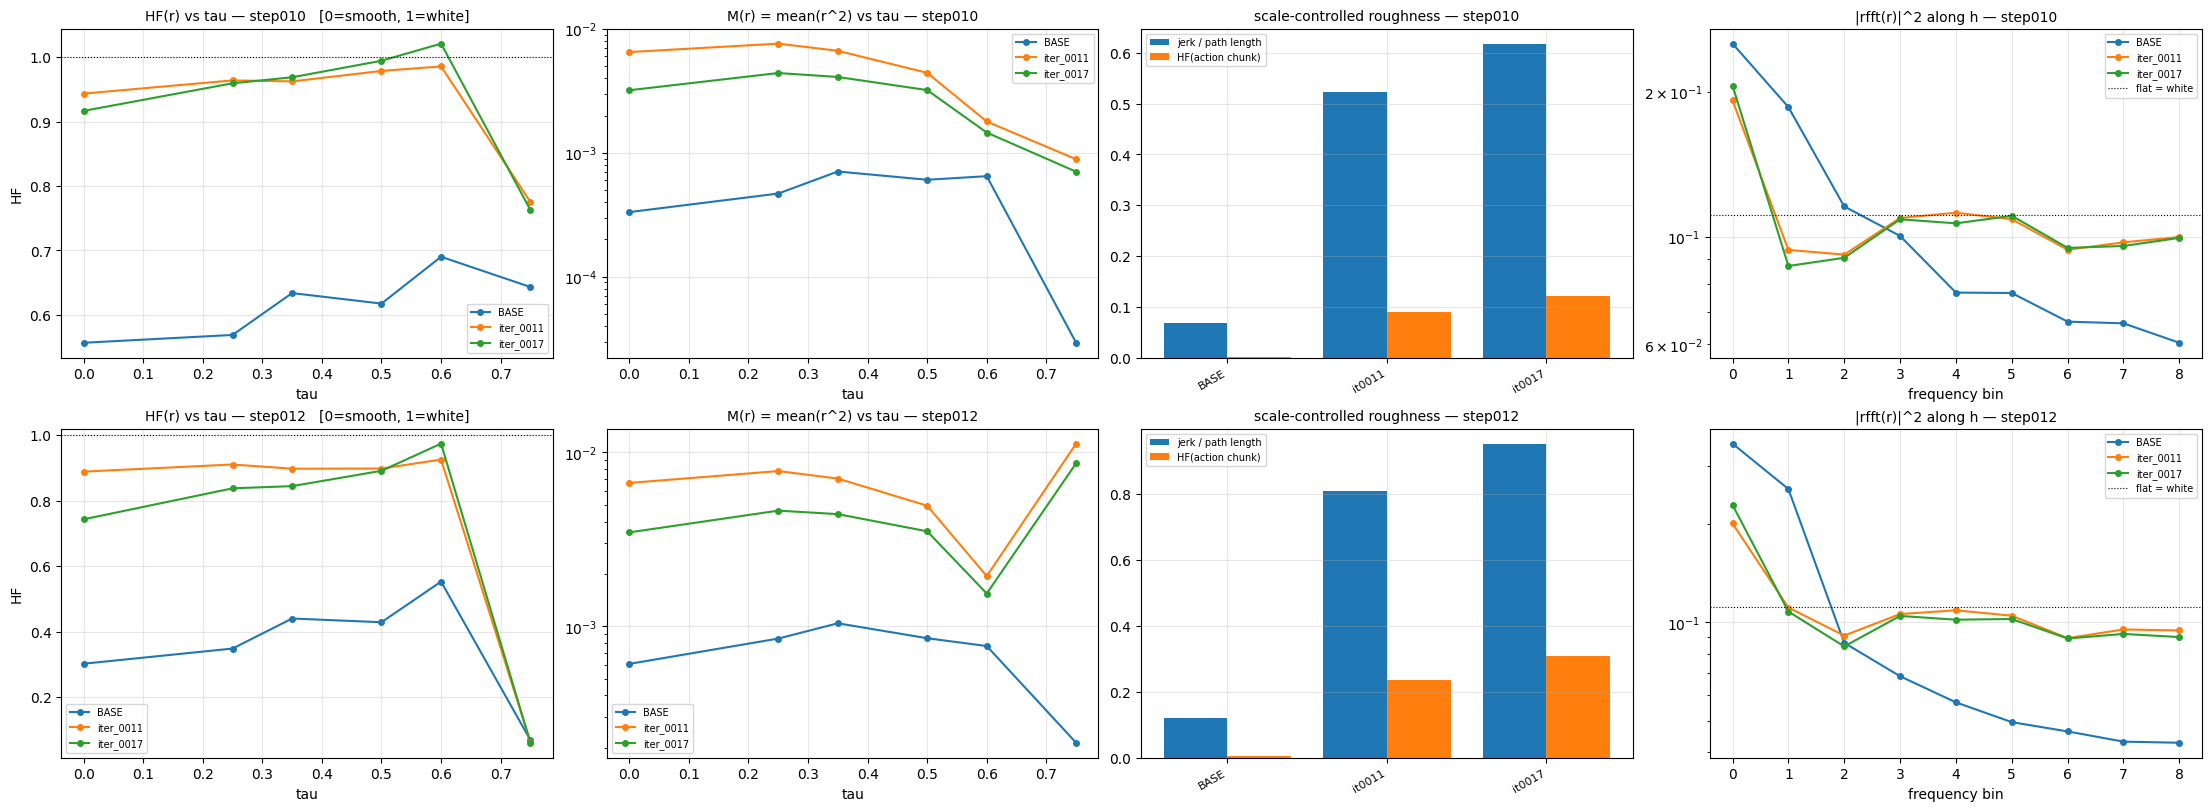

In [28]:
# Cell 12: same measurement for step012, then plot HF(tau) and M(tau) for both
# observations. HF is the new signal; M is the sanity check against ref_mse/mean.
_feat_012, res_012 = measure_all_checkpoints(
    "/home/ubuntu/results/npz_save_CoffeeServeMug_v2/ep000_step012.npz")
report(res_012, "ep000_step012.npz")

fig, axes = plt.subplots(2, 4, figsize=(22, 8), constrained_layout=True)
for row, (res, name) in enumerate([(res_010, "step010"), (res_012, "step012")]):
    for k, v in res.items():
        axes[row, 0].plot(v["taus"], v["HF"], "-o", label=k, markersize=4)
        axes[row, 1].plot(v["taus"], v["M"], "-o", label=k, markersize=4)
    axes[row, 0].set_title(f"HF(r) vs tau — {name}   [0=smooth, 1=white]", fontsize=10)
    axes[row, 0].set_xlabel("tau"); axes[row, 0].set_ylabel("HF")
    axes[row, 0].axhline(1.0, color="k", ls=":", lw=0.8)
    axes[row, 1].set_title(f"M(r) = mean(r^2) vs tau — {name}", fontsize=10)
    axes[row, 1].set_xlabel("tau"); axes[row, 1].set_yscale("log")
    labels = list(res.keys())
    x = np.arange(len(labels))
    axes[row, 2].bar(x - 0.2, [res[k]["path_jerk"] for k in labels], 0.4,
                     label="jerk / path length")
    axes[row, 2].bar(x + 0.2, [res[k]["act_HF"] for k in labels], 0.4,
                     label="HF(action chunk)")
    axes[row, 2].set_xticks(x)
    axes[row, 2].set_xticklabels([l.replace("iter_", "it") for l in labels],
                                 rotation=30, ha="right", fontsize=8)
    axes[row, 2].set_title(f"scale-controlled roughness — {name}", fontsize=10)
    for k, v in res.items():
        sp = v["spectrum"]
        axes[row, 3].plot(np.arange(len(sp)), sp, "-o", label=k, markersize=4)
    axes[row, 3].axhline(1.0 / len(res["BASE"]["spectrum"]), color="k", ls=":", lw=0.8,
                         label="flat = white")
    axes[row, 3].set_title(f"|rfft(r)|^2 along h — {name}", fontsize=10)
    axes[row, 3].set_xlabel("frequency bin"); axes[row, 3].set_yscale("log")
    for c in range(4):
        axes[row, c].grid(True, alpha=0.3)
        axes[row, c].legend(fontsize=7)
plt.show()
